# Clasificación de textos según los Objetivos de Desarrollo Sostenible

**Micro proyecto 2** de ML No Supervisado (2026-14), Universidad de los Andes
**Autores:** Juan David Lara Camacho, Miguel
**Entrega:** domingo 20 de septiembre de 2026

Se construye una solución de procesamiento de lenguaje natural que toma un texto en español y lo
relaciona con uno de los Objetivos de Desarrollo Sostenible de la Agenda 2030. El recorrido es
TF-IDF sobre bolsa de palabras, reducción de la dimensionalidad con SVD truncada, que a la vez
sirve de modelo de tópicos por análisis semántico latente, y clasificación sobre esa
representación.

---

### Cómo está organizado este notebook

El orden de las secciones es el de los criterios de evaluación, para que cada bloque se pueda
leer y calificar por separado.

| Sección | Qué construye | Peso |
|---|---|---|
| 1 | Los datos: carga, distribución de clases y partición | |
| 2 | Preparación de los textos y **pipeline** | 30% + 15% |
| 3 | **LSA**: tópicos e interpretación frente a los ODS | 15% |
| 4 | **Clasificación** con búsqueda de hiperparámetros | 30% |
| 5 | Desempeño sobre textos **no vistos** | 10% |
| 6 | Conclusiones | |
| 7 | Anexo: aplicación interactiva | bonificación |

## 1. Los datos

El corpus es un subconjunto del **OSDG Community Dataset** en su versión 2023, traducido al
español y aumentado. Tres hechos medidos antes de empezar, que condicionan todo lo que sigue:

1. **Son 16 clases, no 17.** El ODS 17, alianzas para lograr los objetivos, no aparece en el
   archivo. No es un descuido del corpus: en las taxonomías oficiales el ODS 17 es el medio de
   implementación de los demás y no un tema comparable.
2. **Desbalance de 3,5 a 1** entre el ODS 16, con 1.080 textos, y el ODS 12, con 312. La
   exactitud sola es engañosa: la métrica principal es **F1 macro** y la partición va
   estratificada.
3. **Los textos son párrafos** de mediana 105 palabras, entre 24 y 268.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Nombres cortos de los ODS, para las tablas y las figuras
NOMBRES_ODS = {
    1: "pobreza", 2: "hambre", 3: "salud", 4: "educación", 5: "género", 6: "agua",
    7: "energía", 8: "trabajo", 9: "industria", 10: "desigualdad", 11: "ciudades",
    12: "consumo", 13: "clima", 14: "vida marina", 15: "vida terrestre", 16: "paz",
}

# Dos colores que se siguen distinguiendo con daltonismo, y un gris para las anotaciones
AZUL, VERMELLON, GRIS = "#0072B2", "#D55E00", "#6B6B6B"

### 1.1 Carga

In [2]:
from pathlib import Path

# El corpus se busca junto al notebook, o en una carpeta data/ a su lado o un nivel más arriba
CANDIDATAS = [Path("Train_textosODS.xlsx"), Path("data/Train_textosODS.xlsx"),
              Path("../data/Train_textosODS.xlsx")]
ruta = next((candidata for candidata in CANDIDATAS if candidata.exists()), None)
if ruta is None:
    raise FileNotFoundError("No se encontró Train_textosODS.xlsx. Se buscó en: "
                            + ", ".join(str(candidata) for candidata in CANDIDATAS))

corpus = pd.read_excel(ruta)
print(f"{corpus.shape[0]} textos, {corpus.shape[1]} columnas: {list(corpus.columns)}")
corpus.head(3)

9656 textos, 2 columnas: ['textos', 'ODS']


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13


### 1.2 Distribución de las clases

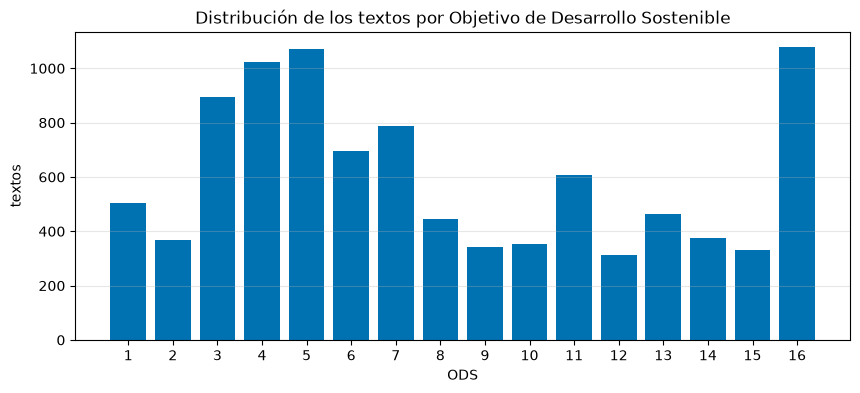

clases presentes: 16 de 17   (falta el ODS 17)
desbalance mayor/menor: 3.46 a 1


In [3]:
conteo = corpus["ODS"].value_counts().sort_index()

fig, eje = plt.subplots(figsize=(10, 4))
eje.bar(conteo.index, conteo.values, color=AZUL)
eje.set_xticks(conteo.index)
eje.set_xlabel("ODS")
eje.set_ylabel("textos")
eje.set_title("Distribución de los textos por Objetivo de Desarrollo Sostenible")
eje.grid(axis="y", alpha=0.3)
plt.show()

print(f"clases presentes: {corpus['ODS'].nunique()} de 17   "
      f"(falta el ODS {min(set(range(1, 18)) - set(corpus['ODS'].unique()))})")
print(f"desbalance mayor/menor: {conteo.max() / conteo.min():.2f} a 1")

### 1.3 Partición estratificada

Se reserva un conjunto de prueba que **no se toca** hasta la sección 5. La estratificación
mantiene la proporción de cada ODS en las dos partes, que con este desbalance no es opcional.
Al comienzo de la sección 5 se comprueba además que la aumentación no haya dejado variantes
casi idénticas de un mismo texto a lado y lado de la partición.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    corpus["textos"].astype(str),
    corpus["ODS"],
    test_size=0.2,
    stratify=corpus["ODS"],
    random_state=RANDOM_STATE,
)

print(f"entrenamiento: {len(X_train)} textos")
print(f"prueba:        {len(X_test)} textos")

entrenamiento: 7724 textos
prueba:        1932 textos


---

## 2. Preparación de los textos y pipeline

> **Criterios:** *preparación de los datos, incluida la reducción de la dimensionalidad,
> justificando las decisiones* (**30%**) y *construcción del pipeline de preparación*
> (**15%**).

Bolsa de palabras con pesado TF-IDF, dentro de un `Pipeline` que después pueda procesar un
texto que nunca vio. La reducción de la dimensionalidad, que también cuenta para el 30%, es la
SVD truncada de la sección 3: cumple doble papel, reducir y servir de modelo de tópicos, y por
eso vive allá.

Cada decisión de esta sección se resuelve con la tabla de la sección 2.4, que mide una variante
a la vez. El resultado, adelantado: **ninguna de ellas mueve el desempeño más allá del ruido
entre particiones**, y eso cambia el criterio con que se escogen.

### 2.1 Normalización del texto

Qué entra al vectorizador. Cuatro decisiones y una trampa.

**Minúsculas y tildes.** Se unifican las dos, con `lowercase=True` y
`strip_accents="unicode"`. En un corpus traducido automáticamente el acentuado suele ser
consistente, así que quitar las tildes no debería aportar mucho, y medido no aporta; tampoco
cuesta, y cubre el acentuado irregular que pueda haber dejado la aumentación.

**Números.** Se descartan, con un patrón de tokens que solo admite letras. La duda era
legítima, porque en un corpus de ODS hay años, porcentajes y metas numeradas, y un token como
"2030" parecía informativo. Medido, conservarlos agrega 229 términos y no mejora nada.

**Palabras vacías.** `TfidfVectorizer` solo trae lista para inglés, así que la aportamos:
174 formas del español, artículos, preposiciones, pronombres, conjunciones y las formas
frecuentes de ser, estar, haber y tener. No incluye vocabulario del dominio. Términos como
"desarrollo" o "países" discriminan poco entre ODS, pero quitarlos a mano sería decidir por el
modelo algo que el pesado IDF ya penaliza por su cuenta.

**Lematización o stemming.** No se aplica, y esta es una decisión de dependencias y no una
medición. Un lematizador exige nltk o spaCy, que el pipeline tendría que cargar también cada
vez que procese un texto nuevo, y como ninguna de las otras decisiones de normalización movió
el desempeño más allá del ruido, no hay razón para esperar que esta sí lo haga.

**La trampa.** El filtro de palabras vacías se aplica *después* del preprocesamiento, es decir
después de quitar las tildes. Una lista acentuada no empareja nada y el filtro queda inerte sin
avisar. La lista va sin tildes.

In [5]:
# Palabras vacías del español, SIN tildes: el filtro se aplica después de strip_accents.
PALABRAS_VACIAS_ES = [
    "a", "al", "algo", "alguna", "algunas", "alguno", "algunos", "algun", "ambos", "ante",
    "antes", "aquel", "aquella", "aquellas", "aquello", "aquellos", "aqui", "asi", "aun",
    "aunque", "bajo", "bien", "cada", "casi", "como", "con", "contra", "cual", "cuales",
    "cualquier", "cuando", "cuanto", "cuya", "cuyo", "de", "debe", "deben", "del", "demas",
    "dentro", "desde", "despues", "donde", "dos", "durante", "e", "el", "ella", "ellas",
    "ello", "ellos", "en", "entre", "era", "eran", "eres", "es", "esa", "esas", "ese", "eso",
    "esos", "esta", "estaba", "estaban", "estado", "estan", "estar", "estas", "este", "esto",
    "estos", "estoy", "fue", "fueron", "fui", "ha", "habia", "habian", "han", "hace", "hacen",
    "hacer", "hacia", "hasta", "hay", "he", "incluso", "la", "las", "le", "les", "lo",
    "los", "mas", "me", "mediante", "menos", "mi", "mientras", "mis", "mucha", "muchas",
    "mucho", "muchos", "muy", "nada", "ni", "no", "nos", "nosotros", "nuestra", "nuestras",
    "nuestro", "nuestros", "o", "otra", "otras", "otro", "otros", "para", "pero", "poco",
    "pocos", "por", "porque", "puede", "pueden", "pues", "que", "quien", "quienes", "se",
    "sea", "sean", "segun", "ser", "si", "sido", "siendo", "sin", "sino", "sobre", "sola",
    "solamente", "solo", "son", "su", "sus", "tal", "tambien", "tampoco", "tan", "tanto",
    "te", "tiene", "tienen", "tener", "toda", "todas", "todo", "todos", "tras", "tu", "tus",
    "un", "una", "unas", "uno", "unos", "usted", "ustedes", "ya", "yo",
]

# Solo letras, dos caracteres o más. La clase [^\W\d_] es "carácter de palabra que no es
# dígito ni guion bajo", es decir letra, con tildes incluidas.
TOKEN_LETRAS = r"(?u)\b[^\W\d_]{2,}\b"

print(f"{len(PALABRAS_VACIAS_ES)} palabras vacías")

174 palabras vacías


### 2.2 Vectorización TF-IDF

Bolsa de palabras con pesado TF-IDF, que es lo que pide el enunciado. Los parámetros que quedan
por fijar, con su argumento:

**`min_df=5`.** Un término tiene que aparecer en al menos cinco documentos para entrar al
vocabulario. Eso lo baja de 15.807 términos a 8.353, la mitad, sin costo en desempeño. El
umbral no sube más por el desbalance: la clase más pequeña, el ODS 12, tiene 312 textos en el
corpus y unos 250 en entrenamiento, de modo que un término presente en cinco de ellos es señal
y no ruido, mientras que un `min_df` de 10 ya exigiría el 4% de esa clase.

**Sin `max_df`.** Medido, el parámetro es inerte en este corpus: el término más frecuente es
"países" y aparece en el 22% de los documentos, así que cualquier umbral razonable no elimina
nada. Se deja en su valor por omisión y se dice, en vez de fijar un número que no hace nada.

**Unigramas.** Los bigramas suben el vocabulario a 13.884 términos y no mejoran el desempeño.

**`sublinear_tf=True`.** Reemplaza la frecuencia del término por uno más su logaritmo. En
párrafos de mediana 105 palabras, un término que aparece cinco veces no es cinco veces más
relevante que uno que aparece una vez. La ganancia medida es de dos milésimas, dentro del
ruido, pero el argumento es el que corresponde a documentos de este tamaño.

Las cifras de las cuatro decisiones están en la tabla de la sección 2.4.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=PALABRAS_VACIAS_ES,
    token_pattern=TOKEN_LETRAS,
    ngram_range=(1, 1),
    min_df=5,
    sublinear_tf=True,
)

matriz = vectorizador.fit_transform(X_train)
print(f"matriz de documentos por términos: {matriz.shape}")
print(f"densidad: {matriz.nnz / (matriz.shape[0] * matriz.shape[1]):.2%}   "
      f"términos por documento: {matriz.nnz / matriz.shape[0]:.0f}")

# Lo que ve el vectorizador de un texto, para no confiar en que la normalización hace lo
# que creemos que hace
analizar = vectorizador.build_analyzer()
print(f"\ntexto:  {X_train.iloc[0][:140]}...")
print(f"tokens: {analizar(X_train.iloc[0])[:14]}")

# La evidencia de que max_df sería inerte: ningún término llega al 25% de los documentos
frecuencia_documental = np.asarray((matriz > 0).sum(axis=0)).ravel() / matriz.shape[0]
terminos = vectorizador.get_feature_names_out()
print("\ntérminos de mayor frecuencia documental:")
for indice in np.argsort(-frecuencia_documental)[:5]:
    print(f"  {terminos[indice]:<14} {frecuencia_documental[indice]:.1%}")

matriz de documentos por términos: (7724, 8353)
densidad: 0.51%   términos por documento: 42

texto:  Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tien...
tokens: ['cabe', 'esperar', 'aumento', 'niveles', 'ingresos', 'posterior', 'reforma', 'asistencia', 'social', 'trabajo', 'tenga', 'efecto', 'positivo', 'ninos']

términos de mayor frecuencia documental:
  paises         22.2%
  desarrollo     18.7%
  embargo        15.1%
  ejemplo        13.5%
  mayor          13.0%


### 2.3 El pipeline

Este es el criterio del 15%, y se pierde entero si se vectoriza a mano en celdas sueltas. Un
`Pipeline` de scikit-learn no es una comodidad de escritura: es lo que garantiza que un texto
nuevo reciba exactamente el mismo tratamiento que los de entrenamiento, con el mismo
vocabulario y los mismos pesos IDF aprendidos, y es lo que hace honesta la validación cruzada
de la sección 4, porque el vectorizador se ajusta dentro de cada partición y no antes de
partir.

El pipeline tiene cuatro pasos: TF-IDF, SVD truncada, normalización de las filas y
clasificador. Se arma en una sola función, `construir_pipeline`, que usan todas las mediciones
del notebook: la tabla de la sección 2.4, las curvas de la sección 3 y la comparación de
algoritmos y la búsqueda de hiperparámetros de la sección 4. Así lo que se mide y lo que se
entrega son el mismo objeto, y cada sección cambia solo el parámetro que discute. El número de
componentes por omisión, mil, es el que cierra la búsqueda de la sección 4; la sección 3
explica por qué hace falta un número de ese orden.

La celda ajusta el bloque de preparación, que es el pipeline sin su último paso, y lo usa sobre
un texto que nunca vio.

In [7]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer

PARAMETROS_TFIDF = vectorizador.get_params()


def construir_pipeline(componentes=1000, clasificador=None, normalizar=True, memoria=None,
                       **cambios_tfidf):
    """Arma el pipeline completo: TF-IDF, SVD truncada, normalización y clasificador.

    Con componentes=None no hay reducción ni normalización, porque TF-IDF ya entrega filas de
    norma uno. cambios_tfidf reemplaza parámetros del vectorizador de la sección 2.2. El
    clasificador por omisión es una regresión logística con su regularización por omisión.
    """
    pasos = [("tfidf", TfidfVectorizer(**{**PARAMETROS_TFIDF, **cambios_tfidf}))]
    if componentes is not None:
        pasos.append(("svd", TruncatedSVD(n_components=componentes, random_state=RANDOM_STATE)))
        if normalizar:
            pasos.append(("norm", Normalizer()))
    if clasificador is None:
        clasificador = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    pasos.append(("clf", clasificador))
    return Pipeline(pasos, memory=memoria)


# El bloque de preparación es el pipeline sin el clasificador
preparacion = construir_pipeline()[:-1]
preparacion.fit(X_train)

# El mismo objeto procesa un texto que nunca vio, con el vocabulario, los IDF y la proyección
# aprendidos en el entrenamiento
texto_nuevo = "Las mujeres rurales enfrentan barreras para acceder a créditos agrícolas."
print(f"un texto nuevo entra como una fila de {preparacion.transform([texto_nuevo]).shape[1]} "
      "coordenadas")

construir_pipeline()

un texto nuevo entra como una fila de 1000 coordenadas


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'al', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.","'(?u)\\b[^\\W\\d_]{2,}\\b'"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",5
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf

### 2.4 Línea base, sin reducción de la dimensionalidad

Esta tabla hace dos cosas a la vez.

La primera es fijar la **línea base**: cuánto rinde el TF-IDF crudo con un clasificador lineal,
sin proyectar a menos dimensiones. Es la vara contra la cual se compara todo lo demás, y en
particular la SVD de la sección 3. Si al proyectar el desempeño cae mucho, hay que decirlo y
explicar por qué se aplica igual.

La segunda es **justificar la preparación**. Cada fila cambia una sola decisión de las
secciones 2.1 y 2.2 sobre la configuración elegida, con el mismo clasificador y la misma
validación cruzada estratificada de cinco particiones, así que lo único que varía entre filas
es la decisión que se está discutiendo. Se reporta la desviación del F1 macro entre las cinco
particiones, porque sin ella no hay manera de saber si una diferencia entre filas significa
algo.

El clasificador de esta medición es una regresión logística con sus valores por omisión. No es
todavía una elección de modelo, que es asunto de la sección 4: aquí es un instrumento de
medida, fijo, para que las filas sean comparables. Por la misma razón esta línea base no
tiene su regularización ajustada; la versión ajustada se mide en la sección 4.2, que es donde
se compara contra el modelo final.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Una variante por fila, sobre los parámetros de la sección 2.2
VARIANTES = [
    ("la elegida", {}),
    ("sin quitar palabras vacías", {"stop_words": None}),
    ("conservando las tildes", {"strip_accents": None}),
    ("conservando los números", {"token_pattern": r"(?u)\b\w\w+\b"}),
    ("con bigramas", {"ngram_range": (1, 2)}),
    ("min_df = 2", {"min_df": 2}),
    ("sin sublinear_tf", {"sublinear_tf": False}),
]

particiones = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas = []

for etiqueta, cambios in VARIANTES:
    puntajes = cross_validate(construir_pipeline(componentes=None, **cambios), X_train, y_train,
                              cv=particiones,
                              scoring=["accuracy", "f1_macro"], n_jobs=-1)
    filas.append({
        "configuración": etiqueta,
        "F1 macro": puntajes["test_f1_macro"].mean(),
        "desv. entre particiones": puntajes["test_f1_macro"].std(),
        "exactitud": puntajes["test_accuracy"].mean(),
        "vocabulario": len(TfidfVectorizer(**{**PARAMETROS_TFIDF, **cambios})
                           .fit(X_train).vocabulary_),
    })

comparacion = pd.DataFrame(filas).set_index("configuración")
F1_LINEA_BASE = comparacion.loc["la elegida", "F1 macro"]
comparacion.round(4)

,F1 macro,desv. entre particiones,exactitud,vocabulario
configuración,,,,
la elegida,0.8497,0.0110,0.8747,8353
sin quitar palabras vacías,0.8435,0.0099,0.8703,8511
conservando las tildes,0.8480,0.0121,0.8731,8399
conservando los números,0.8467,0.0090,0.8725,8582
con bigramas,0.8459,0.0078,0.8723,13884
min_df = 2,0.8483,0.0100,0.8731,15807
sin sublinear_tf,0.8477,0.0082,0.8730,8353


**Lo que dice la tabla.** La línea base, con el clasificador sin ajustar, queda en **0,8497 de
F1 macro y 0,8747 de exactitud**. Para 16 clases con un desbalance de 3,5 a 1 es un punto de
partida alto: un clasificador que dijera siempre ODS 16, la clase mayoritaria, daría 0,112 de
exactitud y 0,013 de F1 macro.

Lo más informativo es lo que **no** ocurre. La desviación del F1 macro entre las cinco
particiones está entre 0,008 y 0,012, y **ninguna variante se separa de la elegida por más que
eso**. Las decisiones de preparación de esta sección no son distinguibles del ruido de
partición. La única que se le acerca es quitar las palabras vacías, que cuesta seis milésimas,
y aun así queda dentro de una desviación.

Eso cambia el criterio con que se escogen. Si el desempeño no decide, deciden el tamaño de la
matriz que recibe la SVD y la interpretabilidad de los tópicos de la sección 3, y por eso la
configuración elegida es la de vocabulario pequeño: 8.353 términos contra los 15.807 de
`min_df = 2` y los 13.884 de los bigramas, con el mismo F1 macro. Un espacio de entrada más
pequeño es además menos ocasión de sobreajuste en la búsqueda de hiperparámetros de la
sección 4.

---

## 3. Modelo de tópicos con LSA

> **Criterio:** *construcción del modelo LSA sobre la matriz TF-IDF e interpretación cualitativa
> de al menos 5 tópicos frente a los ODS* (**15%**).

El enunciado pide `TruncatedSVD` sobre la matriz TF-IDF, explorando un número reducido de
componentes, entre 10 y 20, y mostrar para **al menos cinco** de ellas las palabras de mayor
peso. La interpretación cualitativa es lo que se califica, no la tabla de *loadings*.

Una nota de orientación antes de empezar, porque es la fuente habitual de confusión:
`svd.components_` tiene forma (componentes × términos) y es la que da las palabras de cada
tópico, mientras que `svd.transform(X)` tiene forma (documentos × componentes) y da la
representación de cada documento. Los tópicos se leen en la primera; la reducción de la
dimensionalidad es la segunda.

La sección responde dos preguntas que el enunciado junta en una sola: si veinte componentes
producen tópicos interpretables, y si veinte componentes bastan para clasificar dieciséis
clases. Las respuestas medidas son **sí** y **no**, y de ahí sale la decisión de usar dos
descomposiciones distintas.

### 3.1 SVD truncada

Se ajusta sobre la misma matriz TF-IDF de la sección 2, con veinte componentes, que es el
extremo superior del rango sugerido por el enunciado y el que más tópicos deja para interpretar
sin salirse de lo pedido.

In [9]:
from sklearn.decomposition import TruncatedSVD

svd_topicos = TruncatedSVD(n_components=20, random_state=RANDOM_STATE)
Z_topicos = svd_topicos.fit_transform(matriz)

print(f"components_, componentes por términos:   {svd_topicos.components_.shape}")
print(f"transform,   documentos por componentes: {Z_topicos.shape}")
print(f"varianza explicada acumulada por las 20 componentes: "
      f"{svd_topicos.explained_variance_ratio_.sum():.1%}")

components_, componentes por términos:   (20, 8353)
transform,   documentos por componentes: (7724, 20)
varianza explicada acumulada por las 20 componentes: 5.1%


### 3.2 Cuántas componentes: varianza explicada y desempeño

Las veinte componentes explican el 5,1% de la varianza de la matriz TF-IDF. Antes de concluir
algo de ese número conviene saber que en texto es lo normal: la matriz tiene 8.353 columnas casi
ortogonales entre sí y ninguna dirección concentra mucha varianza.

La pregunta que importa no es cuánta varianza se conserva sino cuánta señal útil para
clasificar, y son dos curvas distintas sobre el mismo eje horizontal. Van en dos paneles y no en
dos escalas del mismo eje: la varianza explicada acumulada se lee directamente de la
descomposición, mientras que el F1 macro exige ajustar un clasificador para cada número de
componentes.

En la misma pasada se mide si conviene **normalizar las filas después de proyectar**.
`TfidfVectorizer` entrega filas de norma L2 igual a uno, y la SVD rompe esa propiedad, porque
cada documento conserva solo la parte de sí mismo que cae en el subespacio y esa parte varía de
un documento a otro.

In [10]:
# Curva de varianza: una sola descomposición ancha y su suma acumulada
svd_ancha = TruncatedSVD(n_components=500, random_state=RANDOM_STATE).fit(matriz)
varianza_acumulada = np.cumsum(svd_ancha.explained_variance_ratio_)

# Curva de desempeño: un clasificador por cada número de componentes, con y sin normalizar
COMPONENTES = [10, 15, 20, 30, 50, 100, 200, 300, 500]
curvas = {False: [], True: []}
desviaciones = {False: [], True: []}

for n in COMPONENTES:
    for normaliza in (False, True):
        puntajes = cross_validate(construir_pipeline(componentes=n, normalizar=normaliza),
                                  X_train, y_train, cv=particiones, scoring="f1_macro",
                                  n_jobs=-1)
        curvas[normaliza].append(puntajes["test_score"].mean())
        desviaciones[normaliza].append(puntajes["test_score"].std())
    print(f"  {n:3d} componentes  ({varianza_acumulada[n - 1]:5.1%} de varianza)   "
          f"F1 macro {curvas[True][-1]:.4f} ± {desviaciones[True][-1]:.4f} normalizado, "
          f"{curvas[False][-1]:.4f} sin normalizar")

   10 componentes  ( 3.3% de varianza)   F1 macro 0.6112 ± 0.0129 normalizado, 0.4801 sin normalizar


   15 componentes  ( 4.3% de varianza)   F1 macro 0.7092 ± 0.0133 normalizado, 0.6253 sin normalizar


   20 componentes  ( 5.1% de varianza)   F1 macro 0.7549 ± 0.0019 normalizado, 0.7014 sin normalizar


   30 componentes  ( 6.6% de varianza)   F1 macro 0.7896 ± 0.0042 normalizado, 0.7603 sin normalizar


   50 componentes  ( 9.1% de varianza)   F1 macro 0.8163 ± 0.0034 normalizado, 0.7861 sin normalizar


  100 componentes  (14.2% de varianza)   F1 macro 0.8299 ± 0.0034 normalizado, 0.8052 sin normalizar


  200 componentes  (22.1% de varianza)   F1 macro 0.8377 ± 0.0056 normalizado, 0.8190 sin normalizar


  300 componentes  (28.5% de varianza)   F1 macro 0.8412 ± 0.0038 normalizado, 0.8273 sin normalizar


  500 componentes  (38.3% de varianza)   F1 macro 0.8492 ± 0.0087 normalizado, 0.8324 sin normalizar


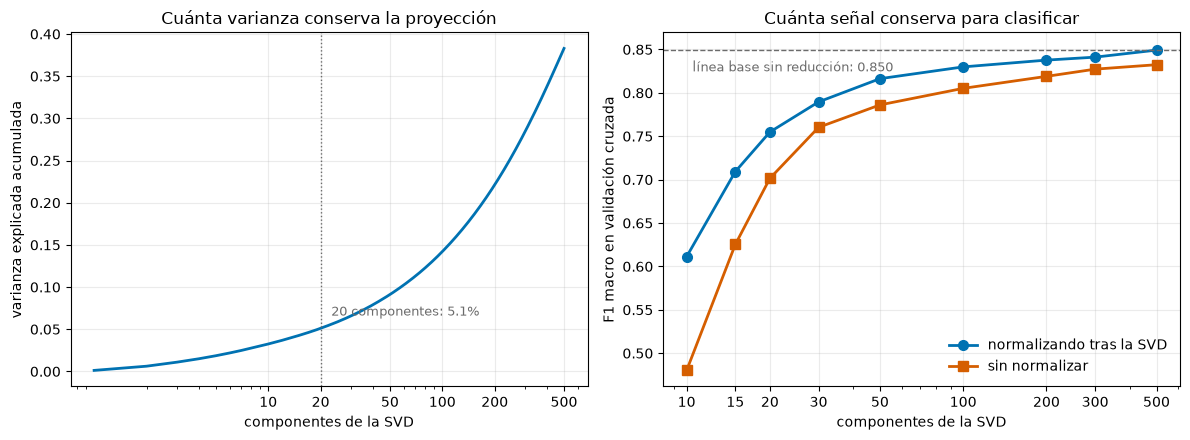

In [11]:
fig, (izquierda, derecha) = plt.subplots(1, 2, figsize=(12, 4.5))

izquierda.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
               color=AZUL, linewidth=2)
izquierda.axvline(20, color=GRIS, linewidth=1, linestyle=":")
izquierda.annotate(f"20 componentes: {varianza_acumulada[19]:.1%}",
                   xy=(23, varianza_acumulada[19] + 0.015), color=GRIS, fontsize=9)
izquierda.set_xscale("log")
izquierda.set_xticks([10, 20, 50, 100, 200, 500])
izquierda.set_xticklabels([10, 20, 50, 100, 200, 500])
izquierda.set_xlabel("componentes de la SVD")
izquierda.set_ylabel("varianza explicada acumulada")
izquierda.set_title("Cuánta varianza conserva la proyección")
izquierda.grid(alpha=0.25)

derecha.plot(COMPONENTES, curvas[True], marker="o", markersize=7, color=AZUL,
             linewidth=2, label="normalizando tras la SVD")
derecha.plot(COMPONENTES, curvas[False], marker="s", markersize=7, color=VERMELLON,
             linewidth=2, label="sin normalizar")
derecha.axhline(F1_LINEA_BASE, color=GRIS, linewidth=1, linestyle="--")
derecha.annotate(f"línea base sin reducción: {F1_LINEA_BASE:.3f}",
                 xy=(10.5, F1_LINEA_BASE - 0.025), color=GRIS, fontsize=9)
derecha.set_xscale("log")
derecha.set_xticks(COMPONENTES)
derecha.set_xticklabels(COMPONENTES)
derecha.set_ylim(top=F1_LINEA_BASE + 0.02)
derecha.set_xlabel("componentes de la SVD")
derecha.set_ylabel("F1 macro en validación cruzada")
derecha.set_title("Cuánta señal conserva para clasificar")
derecha.grid(alpha=0.25)
derecha.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

**Lo que dicen las dos curvas.** Con veinte componentes el F1 macro en validación cruzada es de
**0,755**, contra los **0,850** de la línea base sin reducción. Son casi diez puntos, y la
desviación entre particiones en ese punto es de 0,002, así que no hay manera de leerlo como
ruido: **veinte componentes no bastan para separar dieciséis clases.** Recuperar la línea base
exige **quinientas componentes**, donde el F1 macro llega a 0,849 y la diferencia con no reducir
cabe dentro del ruido. Las dos cifras usan el mismo clasificador sin ajustar; con la
regularización ajustada la comparación cambia, y eso se mide en la sección 4.2.

Y eso ocurre aunque quinientas componentes expliquen apenas el 38% de la varianza y veinte el
5,1%. Las dos curvas no son la misma curva: el desempeño sube mucho más rápido al principio y se
aplana mucho antes, porque la varianza de una matriz TF-IDF está repartida entre miles de
direcciones casi ortogonales, mientras que la información que separa los ODS se concentra en
unos pocos cientos de ellas. Conservar varianza y conservar señal no son lo mismo, y quien elija
el número de componentes por la varianza explicada en un problema de texto va a elegir mal.

**Normalizar después de proyectar** es la primera decisión de todo el proyecto que se mueve más
allá del ruido, y su efecto depende del número de componentes: aporta 0,131 de F1 macro con diez
componentes, 0,054 con veinte y 0,017 con quinientas. La razón se puede medir. TF-IDF entrega
filas de norma L2 exactamente uno; tras la SVD de veinte componentes las normas quedan entre
0,060 y 0,512, un factor de 8,6. Esa magnitud es cuánto de cada documento cabe en el subespacio,
que es una propiedad de la proyección y no del tema del texto, y un clasificador lineal la lee
como si fuera señal. Con quinientas componentes la dispersión de normas baja a un factor de 2,5
y el problema casi desaparece, que es exactamente lo que muestra la curva. `Normalizer` se queda
en el pipeline.

**La decisión son entonces dos descomposiciones.** Veinte componentes para los tópicos de las
secciones 3.3 y 3.4, que es lo que pide la actividad 2 del enunciado y el número con que los
tópicos resultan legibles; y una descomposición más ancha para clasificar, cuyo tamaño exacto se
cierra en la búsqueda de hiperparámetros de la sección 4, donde el número de componentes entra
como un hiperparámetro más en vez de fijarse a mano. El enunciado lo autoriza de forma
explícita: la actividad 3 permite reutilizar la descomposición de la actividad 2 **o aplicar
otra técnica de reducción que se considere pertinente**.

### 3.3 Los tópicos, término por término

Para cada componente, los términos de mayor peso positivo y de mayor peso negativo. El signo
importa y suele pasarse por alto: una componente de la SVD no es una lista de palabras sino un
**contraste** entre dos grupos de vocabulario, y se interpreta leyendo los dos extremos.

In [12]:
terminos = vectorizador.get_feature_names_out()

for k in range(8):
    pesos = svd_topicos.components_[k]
    altos = np.argsort(-pesos)[:9]
    bajos = np.argsort(pesos)[:6]
    print(f"componente {k}   (varianza {svd_topicos.explained_variance_ratio_[k]:.3f})")
    print(f"   extremo positivo: {', '.join(terminos[i] for i in altos)}")
    if pesos.min() < 0:
        print(f"   extremo negativo: {', '.join(terminos[i] for i in bajos)}")
    else:
        print("   extremo negativo: no hay, todos los pesos son positivos")
    print()

componente 0   (varianza 0.001)
   extremo positivo: paises, mujeres, desarrollo, politicas, educacion, ocde, agua, mayor, nivel
   extremo negativo: no hay, todos los pesos son positivos

componente 1   (varianza 0.005)
   extremo positivo: mujeres, genero, hombres, laboral, educacion, trabajo, pobreza, igualdad, empleo
   extremo negativo: agua, energia, gestion, desarrollo, uso, recursos

componente 2   (varianza 0.005)
   extremo positivo: derechos, derecho, humanos, internacional, articulo, ley, genero, mujeres, internacionales
   extremo negativo: pobreza, ingresos, paises, energia, ocde, aumento

componente 3   (varianza 0.004)
   extremo positivo: educacion, estudiantes, escuelas, aprendizaje, escuela, atencion, docentes, salud, evaluacion
   extremo negativo: mujeres, pobreza, ingresos, energia, derechos, hombres

componente 4   (varianza 0.004)
   extremo positivo: mujeres, genero, hombres, igualdad, energia, politicas, desarrollo, empresas, participacion
   extremo negativo:

### 3.4 Interpretación frente a los ODS

Los términos de la sección anterior dicen de qué habla cada componente. Para saber si eso
guarda relación con los ODS, en vez de afirmarlo se puede medir: se proyecta el **centroide de
cada ODS** sobre cada componente, es decir la media de las coordenadas de sus textos, y se mira
qué objetivos quedan en cada extremo. Si una componente separa dos grupos de ODS, ahí aparece.

componente 0, proyección de los 16 ODS: entre 0.103 y 0.146, todos del mismo signo


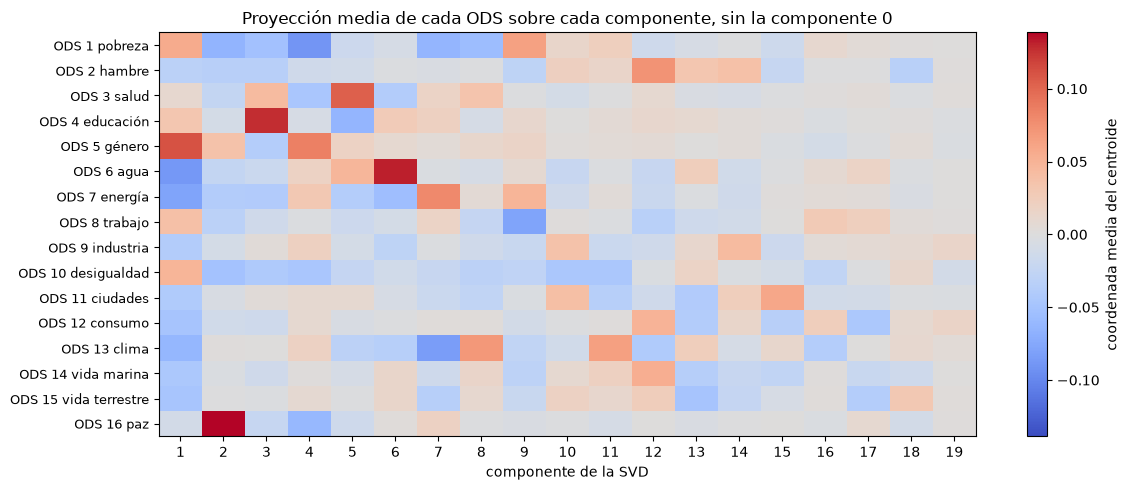


qué contrasta cada componente, los dos ODS de cada extremo
  componente 0   positivo: ODS 5 género, ODS 10 desigualdad   negativo: ODS 14 vida marina, ODS 12 consumo
  componente 1   positivo: ODS 5 género, ODS 1 pobreza   negativo: ODS 6 agua, ODS 7 energía
  componente 2   positivo: ODS 16 paz, ODS 5 género   negativo: ODS 1 pobreza, ODS 10 desigualdad
  componente 3   positivo: ODS 4 educación, ODS 3 salud   negativo: ODS 1 pobreza, ODS 10 desigualdad
  componente 4   positivo: ODS 5 género, ODS 7 energía   negativo: ODS 1 pobreza, ODS 16 paz
  componente 5   positivo: ODS 3 salud, ODS 6 agua   negativo: ODS 4 educación, ODS 7 energía
  componente 6   positivo: ODS 6 agua, ODS 4 educación   negativo: ODS 7 energía, ODS 3 salud
  componente 7   positivo: ODS 7 energía, ODS 4 educación   negativo: ODS 13 clima, ODS 1 pobreza

ODS que dominan un extremo de alguna de las 20 componentes: 16 de 16


In [13]:
centroides = pd.DataFrame(
    {k: [Z_topicos[y_train.values == ods, k].mean() for ods in range(1, 17)]
     for k in range(svd_topicos.n_components)},
    index=[f"ODS {ods} {NOMBRES_ODS[ods]}" for ods in range(1, 17)],
)

# La componente 0 es la dirección media del corpus: todos los ODS proyectan parecido sobre
# ella. Se deja fuera del mapa porque su magnitud aplastaría la escala de color del resto.
print(f"componente 0, proyección de los 16 ODS: entre {centroides[0].min():.3f} y "
      f"{centroides[0].max():.3f}, todos del mismo signo")

restantes = centroides.iloc[:, 1:]
extremo = np.abs(restantes.values).max()

fig, eje = plt.subplots(figsize=(12, 5))
imagen = eje.imshow(restantes.values, cmap="coolwarm", vmin=-extremo, vmax=extremo,
                    aspect="auto")
eje.set_xticks(range(restantes.shape[1]))
eje.set_xticklabels(restantes.columns)
eje.set_yticks(range(16))
eje.set_yticklabels(restantes.index, fontsize=9)
eje.set_xlabel("componente de la SVD")
eje.set_title("Proyección media de cada ODS sobre cada componente, sin la componente 0")
fig.colorbar(imagen, ax=eje, label="coordenada media del centroide")
plt.tight_layout()
plt.show()

print("\nqué contrasta cada componente, los dos ODS de cada extremo")
for k in range(8):
    orden = centroides[k].sort_values()
    print(f"  componente {k}   positivo: {orden.index[-1]}, {orden.index[-2]}"
          f"   negativo: {orden.index[0]}, {orden.index[1]}")

dominan = {extremo_ods for k in range(svd_topicos.n_components)
           for extremo_ods in (centroides[k].idxmax(), centroides[k].idxmin())}
print(f"\nODS que dominan un extremo de alguna de las {svd_topicos.n_components} "
      f"componentes: {len(dominan)} de 16")

**La lectura de los tópicos.** Siete de las veinte componentes se interpretan sin esfuerzo, y
cinco de ellas corresponden a un ODS reconocible cada una.

**La componente 0 no es un tópico**, es el documento promedio. Todos sus pesos son positivos,
sus términos principales son el vocabulario genérico del corpus (países, mujeres, desarrollo,
políticas) y los dieciséis ODS proyectan sobre ella con valores parecidos, entre 0,103 y 0,146.
Por eso es también la componente de menor varianza explicada, 0,001: todos los documentos se le
parecen, así que no distingue nada. En LSA la primera componente suele ser esto y conviene
decirlo antes de que parezca un hallazgo.

**La componente 1 es el eje grande del corpus**, y es el resultado más interesante de la
sección. Su extremo positivo es mujeres, género, hombres, laboral, educación, trabajo y pobreza;
su extremo negativo es agua, energía, gestión, recursos y uso. En centroides, los ODS 5 género,
1 pobreza y 10 desigualdad contra los ODS 6 agua, 7 energía y 13 clima. Es decir: **asuntos
humanos contra sistemas técnicos y ambientales**, que es exactamente la primera partición de la
estructura temática de la Agenda 2030, obtenida aquí por una vía independiente, sin usar las
etiquetas para construir la componente.

Las cinco que corresponden a un objetivo único, que son las que cumplen el criterio del
enunciado:

| Componente | Términos del extremo positivo | ODS | Centroide |
|---|---|---|---|
| 2 | derechos, derecho, humanos, internacional, artículo, ley, justicia | **16** paz y justicia | 0,139, más del triple del siguiente |
| 3 | educación, estudiantes, escuelas, aprendizaje, docentes, escolar | **4** educación | 0,127 |
| 5 | salud, atención, servicios, mental, pacientes, médicos, primaria | **3** salud | el más alto de la componente |
| 6 | agua, aguas, subterráneas, residuales, hídricos, riego, potable | **6** agua | 0,132 |
| 7 | energía, electricidad, renovables, energética, generación | **7** energía | contra el 13 clima en el extremo opuesto |

La componente 7 merece una nota: separa energía de cambio climático, poniéndolos en extremos
opuestos. Son dos objetivos que comparten casi todo el vocabulario y que un clasificador
confunde con facilidad, y la descomposición encuentra de todas formas la dirección que los
distingue.

**Y aquí está la reconciliación de las dos respuestas de esta sección.** Entre las veinte
componentes, los dieciséis ODS dominan un extremo de alguna: ninguno queda sin representación.
Las veinte componentes **alcanzan para nombrar los dieciséis objetivos, no para separarlos**. Es
la misma distinción que separa un modelo de tópicos de un clasificador, y es la razón por la
cual la actividad 2 y la actividad 3 del enunciado piden cosas distintas de la misma
descomposición.

---

## 4. Modelo de clasificación

> **Criterio:** *construcción de un modelo de clasificación con búsqueda de hiperparámetros,
> validado con medidas de evaluación adecuadas. Se justifica la selección del algoritmo y de las
> métricas. Se aplica reducción de la dimensionalidad* (**30%**).

El enunciado deja libre el algoritmo y exige justificarlo. La sección compara candidatos sobre
la misma representación, busca los hiperparámetros del que gana y explica por qué las métricas
son las que son. El número de componentes de la SVD entra en la búsqueda como un hiperparámetro
más, que es la manera de cerrar la decisión que quedó abierta en la sección 3.

### 4.1 Elección del algoritmo

Cinco algoritmos, uno de ellos en dos variantes, sobre la misma representación, trescientas
componentes normalizadas, con la misma validación cruzada estratificada. Trescientas, y no el
número final, porque aquí solo se compara entre algoritmos, y el número exacto de componentes
se decide en la búsqueda de la sección 4.2.

Lo que aporta cada uno, antes de ver los números. La **regresión logística** entrega
probabilidades, que la sección 5 necesita para ordenar los dos objetivos más plausibles; qué
tan bien calibradas están se mide allá. El **SVM lineal** suele ganar en texto disperso, pero
aquí el espacio ya no es disperso y no entrega probabilidades directas. El **bosque
aleatorio** captura interacciones entre componentes.
**k vecinos** es coherente con el espíritu del curso y con una representación donde la distancia
coseno significa algo. **Naive Bayes gaussiano** es la línea de referencia barata. Y se prueba
`class_weight="balanced"`, que con un desbalance de 3,5 a 1 es la respuesta de manual.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

CANDIDATOS = [
    ("regresión logística", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("regresión logística, balanced",
     LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ("SVM lineal", LinearSVC(random_state=RANDOM_STATE)),
    ("k vecinos, k = 15, coseno",
     KNeighborsClassifier(n_neighbors=15, metric="cosine", weights="distance")),
    ("naive Bayes gaussiano", GaussianNB()),
    ("bosque aleatorio, 300 árboles",
     RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
]

filas = []
for nombre, clasificador in CANDIDATOS:
    puntajes = cross_validate(construir_pipeline(componentes=300, clasificador=clasificador),
                              X_train, y_train, cv=particiones,
                              scoring=["accuracy", "f1_macro"], n_jobs=-1)
    filas.append({"algoritmo": nombre,
                  "F1 macro": puntajes["test_f1_macro"].mean(),
                  "desv. entre particiones": puntajes["test_f1_macro"].std(),
                  "exactitud": puntajes["test_accuracy"].mean()})
    print(f"  {nombre:<32} F1 {filas[-1]['F1 macro']:.4f}")

pd.DataFrame(filas).set_index("algoritmo").round(4)

  regresión logística              F1 0.8412


  regresión logística, balanced    F1 0.8387


  SVM lineal                       F1 0.8391


  k vecinos, k = 15, coseno        F1 0.8048


  naive Bayes gaussiano            F1 0.8074


  bosque aleatorio, 300 árboles    F1 0.7859


,F1 macro,desv. entre particiones,exactitud
algoritmo,,,
regresión logística,0.8412,0.0038,0.8681
"regresión logística, balanced",0.8387,0.0041,0.8635
SVM lineal,0.8391,0.0076,0.8669
"k vecinos, k = 15, coseno",0.8048,0.0025,0.8383
naive Bayes gaussiano,0.8074,0.0053,0.8338
"bosque aleatorio, 300 árboles",0.7859,0.0097,0.8265


**La regresión logística gana**, con 0,8412 de F1 macro, y el SVM lineal queda a tres
milésimas, dentro del ruido. Los tres candidatos no lineales pierden de forma clara: el bosque
aleatorio se queda en 0,7859, casi seis puntos por debajo, y k vecinos y naive Bayes rondan
0,805. Es el resultado esperable y conviene decir por qué: las componentes de la SVD ya son
combinaciones lineales de términos ajustadas a la estructura del corpus, de modo que la frontera
útil en ese espacio es aproximadamente lineal, y un modelo que busca interacciones entre
componentes gasta capacidad en una estructura que no está ahí.

Entre la logística y el SVM decide la sección 5: se necesitan **probabilidades** para poder
entregar los dos objetivos más plausibles con su confianza, y `LinearSVC` no las da sin un paso
adicional de calibración.

**`class_weight="balanced"` no ayuda**, 0,8387 contra 0,8412. Vale la pena decirlo porque es
contraintuitivo: con un desbalance de 3,5 a 1 lo de manual sería reponderar. La razón es que el
desbalance de este corpus es moderado y la clase más pequeña tiene 312 textos, suficientes para
estimar su frontera; reponderar solo mueve el umbral a favor de clases que no lo necesitaban y
le cuesta precisión a las grandes. Se deja sin reponderar, y el F1 macro, que promedia las clases
sin ponderar por su tamaño, se encarga de que las pequeñas sigan contando igual.

### 4.2 Búsqueda de hiperparámetros

Dos ejes, y el primero es el que quedó abierto en la sección 3:

- **`svd__n_components`**, entre 300, 500, 1.000 y 2.000. La curva de la sección 3.2 seguía
  subiendo en quinientas, así que la rejilla va más allá: con el óptimo en el borde del espacio
  explorado no se puede saber si el desempeño ya se estabilizó.
- **`clf__C`**, la inversa de la fuerza de regularización, entre 0,3 y 10 en pasos
  aproximadamente logarítmicos.

El criterio es **F1 macro**, por la razón que explica la sección 4.3, con la **regla de una
desviación**: entre las combinaciones cuyo F1 macro medio queda a menos de una desviación entre
particiones de la mejor, se escoge la de menos componentes. Una diferencia menor que esa
desviación no se distingue del ruido, y el número de componentes tiene un costo que el F1 no
muestra: la matriz de la SVD, de componentes por términos, es casi todo el tamaño del modelo.

Dieciséis combinaciones por cinco particiones son ochenta ajustes, y cada uno recalcularía la
SVD. El argumento `memory` del `Pipeline` guarda en caché las transformaciones ya calculadas, de
modo que la descomposición se ajusta una vez por partición y por número de componentes, y no una
vez por combinación.

Al lado se busca también la regularización de la **línea base sin reducción**. Sin eso la
comparación sería injusta: el modelo reducido con su `C` ajustado contra el TF-IDF con el `C`
por omisión.

In [15]:
import tempfile

from sklearn.model_selection import GridSearchCV


def menos_componentes_dentro_de_una_desviacion(resultados):
    """Índice de la combinación con menos componentes cuyo F1 macro medio queda a menos de una
    desviación entre particiones de la mejor. Entre empates en componentes, la de mayor F1."""
    medias = np.asarray(resultados["mean_test_score"])
    mejor = np.argmax(medias)
    umbral = medias[mejor] - resultados["std_test_score"][mejor]
    componentes = np.asarray(resultados["param_svd__n_components"], dtype=int)
    admisibles = np.flatnonzero(medias >= umbral)
    return min(admisibles, key=lambda i: (componentes[i], -medias[i]))


# La caché vive fuera del proyecto, en el directorio temporal del sistema
cache = tempfile.mkdtemp()

REJILLA = {"svd__n_components": [300, 500, 1000, 2000], "clf__C": [0.3, 1, 3, 10]}
busqueda = GridSearchCV(construir_pipeline(memoria=cache), REJILLA, scoring="f1_macro",
                        cv=particiones, refit=menos_componentes_dentro_de_una_desviacion,
                        n_jobs=-1)
busqueda.fit(X_train, y_train)

# La línea base sin reducción, con su propia búsqueda de C
busqueda_base = GridSearchCV(construir_pipeline(componentes=None), {"clf__C": [1, 3, 10, 30]},
                             scoring="f1_macro", cv=particiones, n_jobs=-1)
busqueda_base.fit(X_train, y_train)

F1_ELEGIDA = busqueda.cv_results_["mean_test_score"][busqueda.best_index_]
F1_BASE_AJUSTADA = busqueda_base.best_score_
print(f"hiperparámetros elegidos:            {busqueda.best_params_}")
print(f"F1 macro de la elegida:              {F1_ELEGIDA:.4f}")
print(f"F1 macro de la mejor combinación:    {busqueda.cv_results_['mean_test_score'].max():.4f}")
print(f"línea base sin reducción, ajustada:  {F1_BASE_AJUSTADA:.4f}   "
      f"con {busqueda_base.best_params_}")


def contar_parametros(pipeline):
    """Números que guarda el pipeline ajustado: la matriz de la SVD y los del clasificador."""
    clasificador = pipeline.named_steps["clf"]
    svd = pipeline.named_steps.get("svd")
    return (0 if svd is None else svd.components_.size,
            clasificador.coef_.size + clasificador.intercept_.size)


def miles(numero):
    """Con punto como separador de miles, como se escriben los números en español."""
    return f"{numero:,}".replace(",", ".")


for nombre, pipeline in [("modelo reducido", busqueda.best_estimator_),
                         ("sin reducción", busqueda_base.best_estimator_)]:
    en_svd, en_clasificador = contar_parametros(pipeline)
    print(f"{nombre:<16} parámetros: {miles(en_svd + en_clasificador):>10}   "
          f"SVD {miles(en_svd)}, clasificador {miles(en_clasificador)}")

resultados = pd.DataFrame(busqueda.cv_results_)
resultados = (resultados[["param_svd__n_components", "param_clf__C",
                          "mean_test_score", "std_test_score"]]
              .sort_values("mean_test_score", ascending=False)
              .set_index(["param_svd__n_components", "param_clf__C"]))
resultados.round(4)

hiperparámetros elegidos:            {'clf__C': 3, 'svd__n_components': 1000}
F1 macro de la elegida:              0.8556
F1 macro de la mejor combinación:    0.8614
línea base sin reducción, ajustada:  0.8640   con {'clf__C': 30}
modelo reducido  parámetros:  8.369.016   SVD 8.353.000, clasificador 16.016
sin reducción    parámetros:    133.664   SVD 0, clasificador 133.664


mean_test_score  std_test_score
param_svd__n_components param_clf__C                                 
2000                    10.0                   0.8614          0.0068
                        3.0                    0.8613          0.0074
1000                    3.0                    0.8556          0.0089
                        10.0                   0.8541          0.0084
                        1.0                    0.8537          0.0094
2000                    1.0                    0.8536          0.0105
500                     3.0                    0.8511          0.0072
                        1.0                    0.8492          0.0087
                        10.0                   0.8415          0.0075
300                     1.0                    0.8412          0.0038
                        3.0                    0.8403          0.0051
                        0.3                    0.8319          0.0079
                        10.0                   0.8303          0.0046
500                     0.3                    0.8303          0.0084
1000                    0.3                    0.8256          0.0102
2000                    0.3                    0.8108          0.0075

**La regla escoge mil componentes y `C = 3`**, con 0,8556 de F1 macro en validación cruzada.
La mejor combinación de la rejilla es de dos mil componentes y `C = 10`, con 0,8614 y una
desviación de 0,007 entre particiones; mil componentes quedan dentro de esa desviación y
quinientas no, porque su mejor valor es 0,8511. Se pagan menos de seis milésimas de F1 macro por
un modelo de la mitad del tamaño.

**El número de componentes pesa más que la regularización.** Con cada número de componentes el
mejor `C` está entre 1 y 10, y el F1 macro sube con las componentes: 0,841 con trescientas,
0,851 con quinientas, 0,856 con mil y 0,861 con dos mil. La curva de la sección 3.2 no se había
estabilizado en quinientas, y por eso la rejilla tenía que ir más allá.

**Sobre la reducción de la dimensionalidad, con todas sus letras**, porque es lo que la rúbrica
premia. Con la regularización ajustada, la línea base sin reducir llega a 0,8640 con `C = 30`,
prácticamente lo mismo que con `C = 10`. El modelo elegido queda ocho milésimas por debajo, del
orden de una desviación entre particiones, y el de dos mil componentes a tres milésimas. **La SVD
no mejora el desempeño: en el mejor caso lo iguala.** Tampoco achica el modelo. La matriz de la
SVD guarda mil componentes por 8.353 términos, más de ocho millones de números, contra los
133.664 de la regresión logística sobre TF-IDF: el modelo reducido es unas sesenta veces más
grande.

Lo que la reducción sí aporta es otra cosa. El clasificador trabaja sobre mil coordenadas densas y
no sobre 8.353 dispersas, y eso es lo que permitió comparar en la sección 4.1 algoritmos que no
aceptan matrices dispersas, como naive Bayes gaussiano, o que se degradan en espacios muy
grandes, como k vecinos. Y la misma técnica, con veinte componentes, da los tópicos
interpretables de la sección 3. La reducción se justifica por lo que habilita y porque el
enunciado la exige, con su costo medido; presentarla como una mejora sería falsear el
resultado.

### 4.3 Las métricas, y por qué estas

**F1 macro es la métrica principal y la exactitud va al lado.** Con dieciséis clases y un
desbalance de 3,5 a 1, la exactitud se deja llevar por las clases grandes: los ODS 16, 5 y 4
suman el 33% del corpus, así que un modelo que los acierte y descuide el ODS 12 puede verse bien
en exactitud y ser inservible para el UNFPA, que necesita las dieciséis categorías. El F1 macro
promedia el F1 de cada clase sin ponderar por su tamaño, de modo que fallar en una clase pequeña
cuesta lo mismo que fallar en una grande.

Las dos se reportan juntas, y **la distancia entre ellas es informativa**: si la exactitud sube y
el F1 macro no, el modelo está sacrificando las clases pequeñas.

A esto la sección 5 le agrega el desglose por clase, la matriz de confusión y la exactitud
**top-2**, que es la métrica que corresponde al uso real del sistema. La evidencia va allá y no
aquí porque se mide sobre los textos que el modelo nunca vio.

In [16]:
import shutil

modelo = busqueda.best_estimator_

# La caché era solo para la búsqueda: se desconecta del modelo final y se borra del disco
modelo.memory = None
shutil.rmtree(cache, ignore_errors=True)
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](16,)","[ 1, 2, 3,...,14,15,16]"
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'al', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.","'(?u)\\b[^\\W\\d_]{2,}\\b'"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof docu

---

## 5. Desempeño sobre textos no vistos

> **Criterio:** *evidencia del desempeño del modelo sobre textos que no fueron usados en el
> aprendizaje* (**10%**).

Los 1.932 textos apartados en la sección 1.3 no han intervenido en nada de lo anterior: ni en el
vocabulario del vectorizador, ni en la descomposición, ni en la búsqueda de hiperparámetros. Es
la primera y única vez que se usan.

Antes de medir hay una comprobación que el corpus obliga a hacer. La aumentación con un modelo
de lenguaje podría haber dejado variantes casi idénticas de un mismo texto a lado y lado de la
partición, y entonces la prueba no sería sobre textos nuevos. Se mide, para cada texto de
prueba, su similitud coseno TF-IDF con el texto de entrenamiento más parecido.

In [17]:
# Las filas de TF-IDF tienen norma uno, así que el producto punto es la similitud coseno
similitud = (vectorizador.transform(X_test) @ matriz.T).max(axis=1).toarray().ravel()

print(f"similitud con el texto de entrenamiento más parecido: mediana {np.median(similitud):.3f}, "
      f"percentil 99 {np.percentile(similitud, 99):.3f}, máximo {similitud.max():.3f}")
for umbral in (0.9, 0.8, 0.7):
    print(f"  textos de prueba con similitud de {umbral} o más: {(similitud >= umbral).sum()}")

similitud con el texto de entrenamiento más parecido: mediana 0.217, percentil 99 0.560, máximo 0.895
  textos de prueba con similitud de 0.9 o más: 0
  textos de prueba con similitud de 0.8 o más: 2
  textos de prueba con similitud de 0.7 o más: 3


**Ningún texto de prueba es una copia de uno de entrenamiento.** La similitud con el texto más
parecido tiene mediana 0,217, ningún texto llega a 0,9 y solo dos pasan de 0,8. La aumentación
reescribió en vez de copiar, y lo que sigue mide el desempeño sobre textos nuevos. La
comprobación tiene un límite que conviene declarar: TF-IDF no detecta una paráfrasis del mismo
original escrita con otro vocabulario, y esa posibilidad no se puede descartar con los datos
disponibles.

In [18]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, top_k_accuracy_score)

prediccion = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)

print(f"conjunto de prueba: {len(y_test)} textos nunca vistos\n")
print(f"exactitud    {accuracy_score(y_test, prediccion):.4f}")
print(f"F1 macro     {f1_score(y_test, prediccion, average='macro'):.4f}")

# Intervalo del F1 macro por remuestreo del conjunto de prueba
generador = np.random.default_rng(RANDOM_STATE)
reales = y_test.values
remuestreos = [f1_score(reales[indices], prediccion[indices], average="macro")
               for indices in generador.integers(0, len(reales), size=(1000, len(reales)))]
inferior, superior = np.percentile(remuestreos, [2.5, 97.5])
print(f"             intervalo del 95% por remuestreo: {inferior:.4f} a {superior:.4f}")
for k in (2, 3):
    print(f"top-{k}        "
          f"{top_k_accuracy_score(y_test, probabilidades, k=k, labels=modelo.classes_):.4f}")

print("\n" + classification_report(
    y_test, prediccion,
    target_names=[f"ODS {ods} {NOMBRES_ODS[ods]}" for ods in modelo.classes_], digits=3))

conjunto de prueba: 1932 textos nunca vistos

exactitud    0.8851
F1 macro     0.8595


             intervalo del 95% por remuestreo: 0.8411 a 0.8767
top-2        0.9586
top-3        0.9752

                       precision    recall  f1-score   support

        ODS 1 pobreza      0.883     0.822     0.851       101
         ODS 2 hambre      0.818     0.851     0.834        74
          ODS 3 salud      0.933     0.927     0.930       179
      ODS 4 educación      0.943     0.971     0.957       205
         ODS 5 género      0.927     0.949     0.938       214
           ODS 6 agua      0.928     0.921     0.924       139
        ODS 7 energía      0.867     0.911     0.889       158
        ODS 8 trabajo      0.632     0.674     0.652        89
      ODS 9 industria      0.773     0.739     0.756        69
   ODS 10 desigualdad      0.703     0.643     0.672        70
      ODS 11 ciudades      0.839     0.852     0.846       122
       ODS 12 consumo      0.877     0.806     0.840        62
         ODS 13 clima      0.874     0.892     0.883        93
   ODS 14 vid

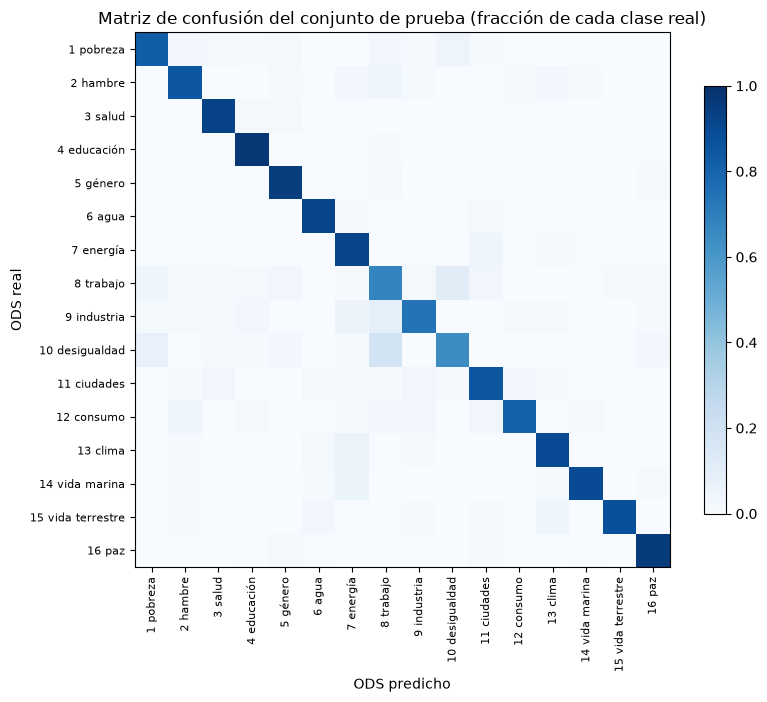

las confusiones más frecuentes, como fracción de la clase real
  ODS 10 desigualdad     se predice como ODS  8 trabajo         18.6%  (13 textos)
  ODS  8 trabajo         se predice como ODS 10 desigualdad     11.2%  (10 textos)
  ODS  9 industria       se predice como ODS  8 trabajo          8.7%  (6 textos)
  ODS 10 desigualdad     se predice como ODS  1 pobreza          7.1%  (5 textos)
  ODS 13 clima           se predice como ODS  7 energía          6.5%  (6 textos)
  ODS  9 industria       se predice como ODS  7 energía          5.8%  (4 textos)


In [19]:
confusiones = confusion_matrix(y_test, prediccion, labels=modelo.classes_)
por_clase = confusiones / confusiones.sum(axis=1, keepdims=True)

fig, eje = plt.subplots(figsize=(8.5, 7))
imagen = eje.imshow(por_clase, cmap="Blues", vmin=0, vmax=1)
etiquetas = [f"{ods} {NOMBRES_ODS[ods]}" for ods in modelo.classes_]
eje.set_xticks(range(16))
eje.set_xticklabels(etiquetas, rotation=90, fontsize=8)
eje.set_yticks(range(16))
eje.set_yticklabels(etiquetas, fontsize=8)
eje.set_xlabel("ODS predicho")
eje.set_ylabel("ODS real")
eje.set_title("Matriz de confusión del conjunto de prueba (fracción de cada clase real)")
fig.colorbar(imagen, ax=eje, shrink=0.8)
plt.tight_layout()
plt.show()

pares = [(por_clase[i, j], modelo.classes_[i], modelo.classes_[j], confusiones[i, j])
         for i in range(16) for j in range(16) if i != j and confusiones[i, j]]
print("las confusiones más frecuentes, como fracción de la clase real")
for fraccion, real, predicho, cuantos in sorted(pares, reverse=True)[:6]:
    print(f"  ODS {real:2d} {NOMBRES_ODS[real]:<15} se predice como "
          f"ODS {predicho:2d} {NOMBRES_ODS[predicho]:<15} {fraccion:5.1%}  ({cuantos} textos)")

**El modelo alcanza 0,8851 de exactitud y 0,8595 de F1 macro sobre textos que nunca vio**, con un
intervalo del 95% por remuestreo entre 0,841 y 0,877. Frente al 0,8556 de la validación cruzada,
la diferencia es de cuatro milésimas, dentro de la desviación entre particiones: el modelo no
estaba sobreajustado a la búsqueda de hiperparámetros.

**El desglose por clase muestra dónde está todo el error.** Los extremos son ODS 4 educación y
ODS 16 paz, con 0,957 y 0,956 de F1, contra ODS 8 trabajo con 0,652, ODS 10 desigualdad con 0,672 y
ODS 9 industria con 0,756. Las otras trece clases pasan de 0,83; el problema está concentrado en
tres.

**Y no es un problema de tamaño de clase, es de solapamiento temático.** El ODS 8 tiene 89 textos
de prueba y el ODS 12 apenas 62, pero el 12 alcanza 0,840 de F1 y el 8 se queda en 0,652. Lo que
distingue a las clases difíciles es con quién se confunden: desigualdad con trabajo en el 18,6%
de los casos, trabajo con desigualdad en el 11,2%, industria con trabajo, desigualdad con
pobreza. Son exactamente los objetivos del bloque de asuntos humanos que la componente 1 de la
sección 3 puso juntos, y los errores del modelo reproducen esa estructura sobre datos que no
intervinieron en construirla. Ningún par de la lista es absurdo: no aparece pobreza confundida
con vida marina, ni educación con clima. **El modelo se equivoca donde un lector humano
dudaría.**

### 5.1 Qué hacer con un problema que no tiene una sola respuesta

La lista de confusiones no describe un modelo defectuoso sino un problema mal planteado por
construcción, y conviene decirlo con la evidencia delante. Los textos vienen del OSDG Community
Dataset, cuyo procedimiento de anotación **nunca permitió a los voluntarios asignar más de un
ODS a un mismo texto**. Un párrafo sobre empleo juvenil femenino en zonas rurales toca los ODS 5,
8 y 10 a la vez, y el corpus está obligado a elegir uno. La etiqueta única no es una propiedad de
los textos, es una restricción de la interfaz con que se recogieron, y la lista de confusiones de
arriba es el modelo tropezando con esa restricción.

Se puede medir. Si la tesis es cierta, los errores deberían ser dudas y no disparates.

In [20]:
orden = np.argsort(-probabilidades, axis=1)
posicion = np.array([list(modelo.classes_[orden[i]]).index(real) + 1
                     for i, real in enumerate(y_test.values)])
fallos = posicion > 1
confianza = probabilidades.max(axis=1)
margen = np.sort(probabilidades, axis=1)[:, -1] - np.sort(probabilidades, axis=1)[:, -2]

print(f"errores: {fallos.sum()} de {len(y_test)}")
print(f"  en {(posicion == 2).sum()} de ellos el ODS correcto quedó segundo "
      f"({(posicion == 2).sum() / fallos.sum():.0%} de los errores)")
print(f"\nconfianza media cuando acierta: {confianza[~fallos].mean():.3f}")
print(f"confianza media cuando falla:   {confianza[fallos].mean():.3f}")
print(f"\ntextos con margen menor que 0,10 entre el primer y el segundo ODS: "
      f"{(margen < 0.10).sum()} ({(margen < 0.10).mean():.1%} del conjunto de prueba)")
print(f"  y concentran el {(fallos & (margen < 0.10)).sum() / fallos.sum():.0%} "
      f"de todos los errores")

# Calibración: en cada tramo de confianza, cuánto acierta el modelo de verdad
calibracion = (pd.DataFrame({"tramo de confianza": pd.cut(confianza, np.linspace(0, 1, 11)),
                             "confianza": confianza, "acierta": ~fallos})
               .groupby("tramo de confianza", observed=True)
               .agg(textos=("acierta", "size"), **{"confianza media": ("confianza", "mean"),
                                                     "exactitud": ("acierta", "mean")}))
error_calibracion = (calibracion["textos"] / len(confianza)
                     * (calibracion["confianza media"] - calibracion["exactitud"]).abs()).sum()
print(f"\nerror de calibración esperado: {error_calibracion:.3f}")
calibracion.round(3)

errores: 222 de 1932
  en 142 de ellos el ODS correcto quedó segundo (64% de los errores)

confianza media cuando acierta: 0.853
confianza media cuando falla:   0.510

textos con margen menor que 0,10 entre el primer y el segundo ODS: 126 (6.5% del conjunto de prueba)
  y concentran el 33% de todos los errores

error de calibración esperado: 0.072


,textos,confianza media,exactitud
tramo de confianza,,,
"(0.1, 0.2]",25,0.169,0.360
"(0.2, 0.3]",65,0.252,0.415
"(0.3, 0.4]",81,0.353,0.593
"(0.4, 0.5]",91,0.457,0.637
"(0.5, 0.6]",101,0.554,0.733
"(0.6, 0.7]",127,0.654,0.843
"(0.7, 0.8]",170,0.752,0.894
"(0.8, 0.9]",203,0.853,0.916
"(0.9, 1.0]",1069,0.973,0.981


**De los 222 errores, en 142 el ODS correcto quedó en segunda posición**, el 64%. La exactitud
top-2 es de **0,9586** contra 0,8851 de top-1. Y la confianza acompaña: 0,853 en promedio cuando
acierta, 0,510 cuando falla. El modelo no se equivoca con seguridad, se equivoca dudando. Los 126
textos donde la diferencia entre el primer y el segundo objetivo es menor que 0,10, el 6,5% del
conjunto de prueba, concentran el 33% de todos los errores.

**Las probabilidades son conservadoras.** La tabla compara, en cada tramo de confianza, la
probabilidad que asigna el modelo con la fracción de aciertos real. Por encima de 0,9 coinciden,
0,973 contra 0,981; por debajo, el modelo acierta más de lo que dice: con confianza entre 0,3 y
0,4 acierta el 59% de las veces. El error de calibración esperado es de 0,072. Para lo que sigue
importa sobre todo el orden de los candidatos, pero una probabilidad baja debe leerse como duda
y no como error probable.

**Esto cambia qué se debería entregar.** El destinatario del enunciado es el UNFPA, que quiere
aliviar el trabajo de expertos que leen textos y los relacionan con los ODS. Para ese usuario, un
sistema que propone **los dos objetivos más probables con su confianza** y acierta el 95,9% de
las veces es más útil que uno que propone uno solo y acierta el 88,5%, porque revisar dos
candidatos cuesta poco y el propio dominio admite que muchos textos tocan dos objetivos. Y los
textos de margen estrecho se pueden marcar como **transversales** en vez de forzarles una
etiqueta.

Nada de esto reemplaza lo que pide la rúbrica: el modelo entrega una clase y se evalúa como
clasificador de clase única. Se reporta **además**, no en lugar de.

### 5.2 Clasificación de textos del conjunto de prueba

El enunciado pide mostrar la clasificación de al menos cuatro textos no usados en el aprendizaje.
Se muestran seis: los cuatro primeros del conjunto de prueba, sin escoger, y los dos de margen
más estrecho de todo el conjunto, que son los que ilustran el párrafo anterior.

In [21]:
seleccion = list(range(4)) + list(np.argsort(margen)[:2])

for lugar in seleccion:
    texto = X_test.iloc[lugar]
    real = y_test.iloc[lugar]
    primero, segundo = modelo.classes_[orden[lugar, 0]], modelo.classes_[orden[lugar, 1]]
    p_primero, p_segundo = probabilidades[lugar, orden[lugar, 0]], probabilidades[lugar, orden[lugar, 1]]
    veredicto = "acierta" if primero == real else "falla"
    estrecho = "  [margen estrecho, texto transversal]" if margen[lugar] < 0.10 else ""

    print(f'"{texto[:260]}..."')
    print(f"  real:      ODS {real} {NOMBRES_ODS[real]}")
    print(f"  predicho:  ODS {primero} {NOMBRES_ODS[primero]} ({p_primero:.1%}), {veredicto}")
    print(f"  segundo:   ODS {segundo} {NOMBRES_ODS[segundo]} ({p_segundo:.1%}){estrecho}")
    print()

"En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como mediadoras principales. Maximizar los beneficios de la participación de las mujeres en la prevención de conflictos y la consolidación de la ..."
  real:      ODS 5 género
  predicho:  ODS 5 género (77.2%), acierta
  segundo:   ODS 16 paz (18.2%)

"La seguridad alimentaria se menciona solo una vez, aunque se reconoce la protección de las personas en el sector rural (por ejemplo, la necesidad de proteger a los hogares contra la mala cosecha), pero estas conexiones (al menos en la documentación formal) son..."
  real:      ODS 2 hambre
  predicho:  ODS 2 hambre (59.8%), acierta
  segundo:   ODS 1 pobreza (15.4%)

"Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización de residuos en Chile fue de aproximadamente 10% en 2009 (CONAMA, 2010). El objetivo principal de la política es gestionar los residuos sóli

**Qué muestran los seis.** Los dos primeros son el caso corriente, acierto con confianza alta y
un segundo candidato que también tiene sentido: participación de mujeres en procesos de paz
queda en ODS 5 con el ODS 16 detrás, y seguridad alimentaria en ODS 2 con el ODS 1 detrás.

**El tercero es el más instructivo y no conviene esconderlo**, porque es el único error confiado
del grupo. El texto habla de gestión, reciclaje y valorización de residuos, y el modelo dice
ODS 12, consumo y producción responsables, con 99,0% de confianza. La etiqueta del corpus dice
ODS 11, ciudades, porque el residuo urbano es competencia municipal. **Los dos tienen razón**, y
ningún esquema de etiqueta única puede resolverlo: es el problema multietiqueta en una sola
línea, y explica por qué el modelo puede estar seguro y aun así no coincidir con el anotador.

El cuarto acierta por poco, género al 36,5% contra educación al 33,8%, sobre un texto que
relaciona nivel educativo con reparto de tareas domésticas, es decir ODS 4 y ODS 5 a la vez; ya
cae en la franja de margen estrecho.

**Los dos últimos son los de margen más estrecho de todo el conjunto de prueba**, con los dos
primeros candidatos empatados en la décima que se muestra. El quinto, sobre producción acuícola,
falla: el modelo dice vida marina y el corpus dice hambre, con 30,5% para cada uno. El sexto,
sobre tecnologías para verificar el origen de la madera, acierta vida terrestre con 23,5%,
empatado con industria. En ambos el sistema haría mejor en marcar el texto como transversal y
devolver los dos candidatos que en forzar una etiqueta: el acierto del sexto y el error del
quinto se deciden por una diferencia que el modelo no puede sostener.

### 5.3 Un texto cualquiera, de principio a fin

Los textos anteriores salen del corpus. Estos tres se escribieron para esta prueba, en el tono de
un documento de planeación territorial, y entran como texto crudo al mismo `modelo`: el pipeline
los normaliza, los vectoriza, los proyecta y los clasifica en una sola llamada.

In [22]:
TEXTOS_LIBRES = [
    "El municipio pondrá en marcha un programa de becas y transporte escolar para que los niños "
    "de las veredas más apartadas terminen la secundaria, junto con la formación de los docentes "
    "rurales en nuevas metodologías de enseñanza.",
    "La comunidad pide apoyo para que las mujeres campesinas accedan a créditos, asistencia "
    "técnica y tierras propias, porque hoy dependen de los ingresos de sus parejas y no "
    "participan en las decisiones sobre la producción de la finca.",
    "Los pescadores artesanales denuncian que la sobrepesca industrial y los vertimientos de "
    "plástico están acabando con los arrecifes y con las especies de las que vive la costa.",
]

for texto, probabilidad in zip(TEXTOS_LIBRES, modelo.predict_proba(TEXTOS_LIBRES)):
    primero, segundo = np.argsort(-probabilidad)[:2]
    print(f'"{texto}"')
    print(f"  predicho:  ODS {modelo.classes_[primero]} {NOMBRES_ODS[modelo.classes_[primero]]} "
          f"({probabilidad[primero]:.1%})")
    print(f"  segundo:   ODS {modelo.classes_[segundo]} {NOMBRES_ODS[modelo.classes_[segundo]]} "
          f"({probabilidad[segundo]:.1%})")
    print()

"El municipio pondrá en marcha un programa de becas y transporte escolar para que los niños de las veredas más apartadas terminen la secundaria, junto con la formación de los docentes rurales en nuevas metodologías de enseñanza."
  predicho:  ODS 4 educación (97.6%)
  segundo:   ODS 11 ciudades (0.8%)

"La comunidad pide apoyo para que las mujeres campesinas accedan a créditos, asistencia técnica y tierras propias, porque hoy dependen de los ingresos de sus parejas y no participan en las decisiones sobre la producción de la finca."
  predicho:  ODS 5 género (71.5%)
  segundo:   ODS 2 hambre (15.0%)

"Los pescadores artesanales denuncian que la sobrepesca industrial y los vertimientos de plástico están acabando con los arrecifes y con las especies de las que vive la costa."
  predicho:  ODS 14 vida marina (91.2%)
  segundo:   ODS 15 vida terrestre (5.5%)



**Los tres salen como los leería una persona.** Las becas y el transporte escolar van a ODS 4
educación con 97,6%, y la sobrepesca y los arrecifes a ODS 14 vida marina con 91,2%. El texto de
las mujeres campesinas va a ODS 5 género con 71,5%, con ODS 2 hambre detrás al 15,0%: es el caso
que describe la sección 5.1, un párrafo que toca a la vez la igualdad de género y la producción
agrícola, y el modelo lo ordena en ese sentido. Los tres entraron como cadenas de texto, sin
ningún tratamiento fuera del pipeline.

---

## 6. Conclusiones

**Lo que se construyó.** Un `Pipeline` de scikit-learn que va del texto en español al ODS
predicho en cuatro pasos: TF-IDF sobre bolsa de palabras con 8.353 términos, SVD truncada a
1.000 componentes, normalización de las filas y regresión logística. Sobre 1.932 textos que
nunca vio alcanza **0,8851 de exactitud y 0,8595 de F1 macro**, con un intervalo del 95% entre
0,841 y 0,877, y **0,9586 si se le permiten dos propuestas**. El mismo objeto procesa un texto
nuevo con un `predict`.

**Las decisiones que lo explican**, en orden de cuánto pesaron:

1. **El número de componentes.** Es la decisión grande. Veinte componentes, el rango que sugiere
   el enunciado, dan 0,755 de F1 macro contra 0,850 sin reducir, con el mismo clasificador sin
   ajustar. Con la regularización ajustada, la búsqueda escoge mil componentes por la regla de
   una desviación. Por eso van dos descomposiciones: veinte para interpretar tópicos y mil para
   clasificar, que el enunciado autoriza de forma explícita.
2. **Normalizar las filas después de proyectar**, que aporta 0,054 de F1 macro con veinte
   componentes y 0,017 con quinientas, porque la SVD rompe la norma unitaria que entrega TF-IDF y
   deja una magnitud espuria que el clasificador lineal lee como señal.
3. **El algoritmo.** La regresión logística gana por entre 3,4 y 5,5 puntos a los candidatos no
   lineales, porque la frontera útil en el espacio de las componentes es aproximadamente lineal.
   Se prefiere al SVM lineal, que empata, porque entrega probabilidades.
4. **La preparación del texto no importó.** Ninguna de las decisiones de normalización y
   vectorización mueve el desempeño más allá del ruido entre particiones, de modo que se
   escogieron por el tamaño del vocabulario. Es un resultado negativo y se reporta como tal.

**Lo que la reducción cuesta.** La SVD no mejora el desempeño ni achica el modelo. Con la
regularización ajustada, no reducir da 0,8640 de F1 macro en validación cruzada, ocho milésimas
por encima del modelo elegido, y la matriz de la SVD hace al modelo unas sesenta veces más grande
que una regresión logística sobre TF-IDF. Se aplica porque el enunciado la exige y por lo que
habilita, componentes interpretables y un espacio denso donde comparar algoritmos, y su costo
queda medido en vez de presentarse como mejora.

**Lo que quedó abierto, y es del problema y no del método.** El corpus impone una etiqueta única
sobre textos que tocan varios objetivos, porque su procedimiento de anotación nunca dio a los
voluntarios la opción de marcar dos. Los errores del modelo lo reflejan: el 64% tiene el ODS
correcto en segunda posición, la confianza media cae de 0,853 cuando acierta a 0,510 cuando
falla, y las confusiones se concentran entre objetivos que la propia Agenda 2030 agrupa. Un
sistema que entregue dos objetivos con su confianza, y marque como transversales los de margen
estrecho, sería más útil para el usuario del enunciado que uno que fuerce una sola respuesta.

**Dos límites que conviene declarar.** El primero es que el corpus está traducido
automáticamente y aumentado con un modelo de lenguaje, así que parte de la estructura observada
podría venir del traductor y no de los textos originales; con los datos disponibles no se puede
descartar. El segundo es que el ODS 17 no aparece en el corpus, de modo que el sistema no lo
puede predecir nunca, y eso hay que decirlo antes de ponerlo a funcionar sobre textos nuevos.

---

## 7. Anexo: aplicación interactiva

La bonificación del enunciado pide una aplicación en Streamlit que reciba texto libre, lo procese
con el mismo pipeline del proyecto y devuelva el ODS predicho. La aplicación usa el pipeline de
este notebook con los hiperparámetros de la sección 4.2, entrenado sobre el corpus completo,
porque ahí se sirve y ya no se mide; las métricas que muestra son las de la sección 5.

Lleva a la interfaz la conclusión de la sección 5.1:

- Devuelve el ODS más probable con su probabilidad.
- Si el segundo queda a menos de 0,10 del primero, marca el texto como transversal y presenta los
  dos.
- Si no hay empate pero el segundo pasa del 10%, lo menciona como alternativa. Si el modelo está
  seguro, no ofrece nada más.
- Muestra los cinco objetivos más probables en un desplegable.
- Advierte cuando el texto tiene menos de 20 palabras, y no clasifica un texto que no contiene
  ningún término del vocabulario, en vez de devolver una predicción sin base.

Las capturas muestran los tres casos.

**Una respuesta clara.** Un párrafo sobre redes de alcantarillado y tratamiento de aguas
residuales va al ODS 6 con 99,8% de probabilidad. El segundo candidato no alcanza el 0,1%, así
que la aplicación no lo menciona.

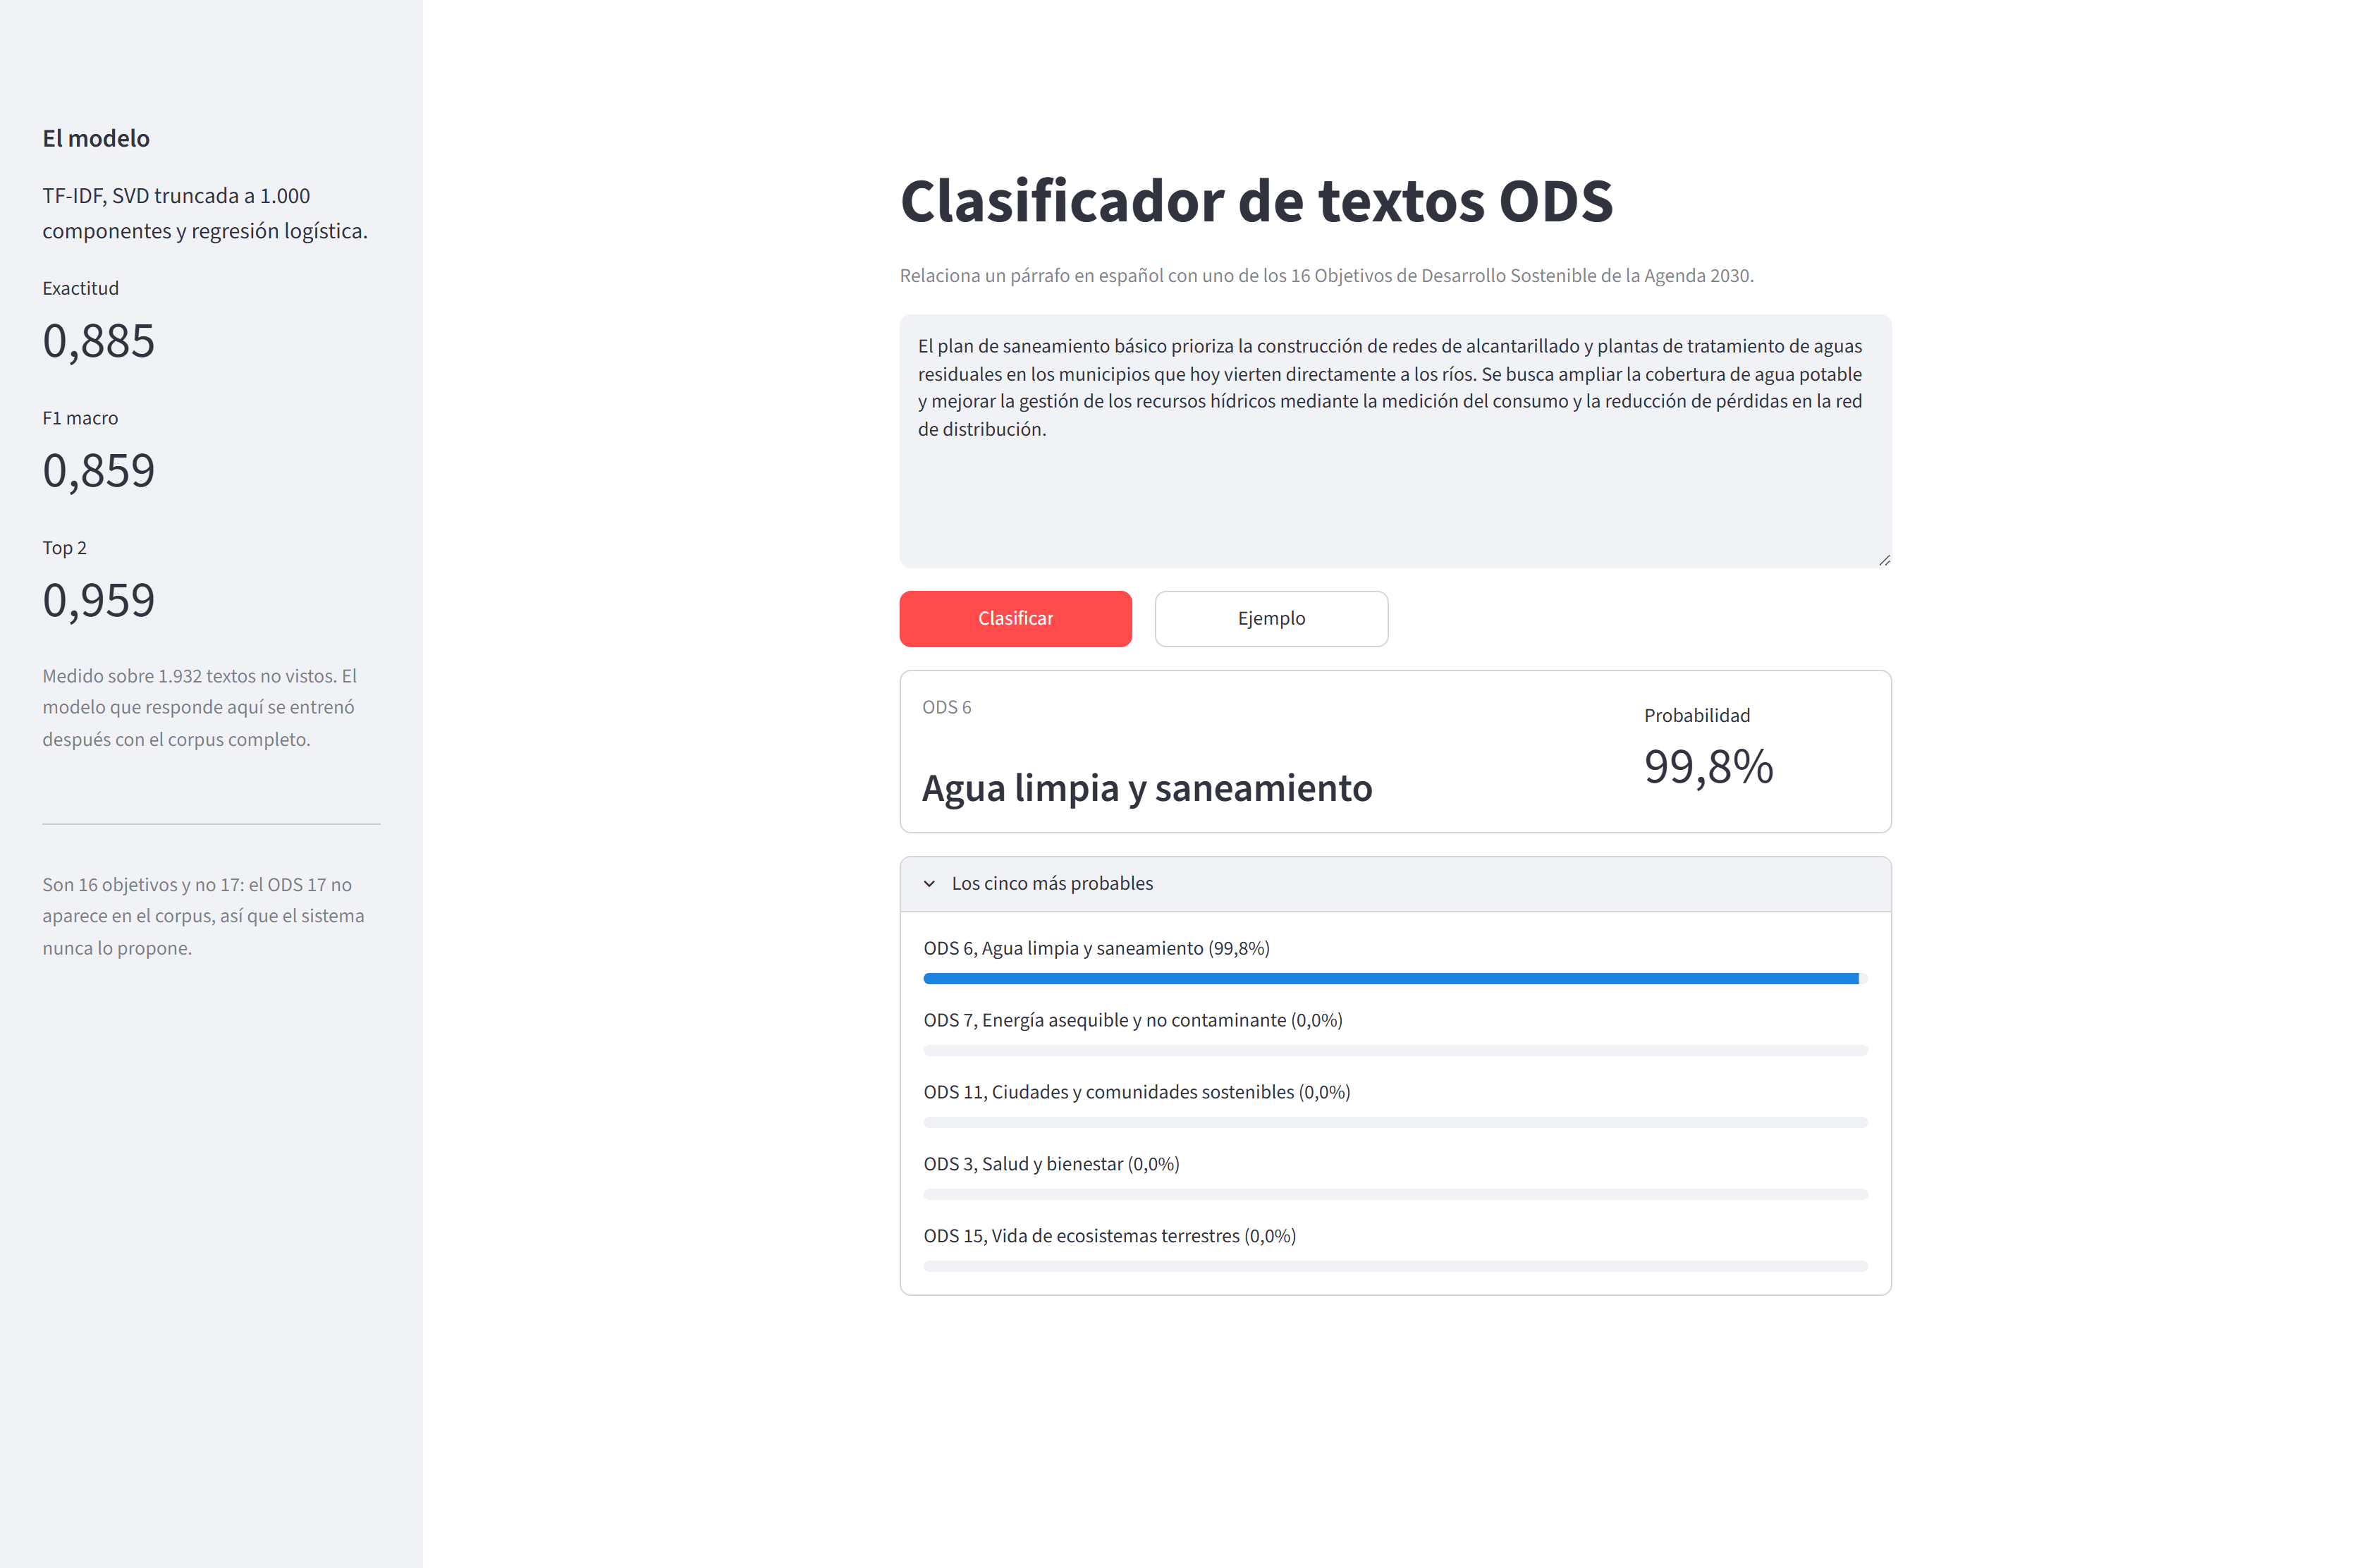

**Un texto transversal.** Un párrafo que habla a la vez de brecha salarial y empleo informal y
de los ingresos de los hogares más pobres deja el ODS 8 en 43,2% y el ODS 1 en 36,0%. La
diferencia no llega a 0,10, de modo que la aplicación presenta los dos en vez de forzar una
etiqueta. Es la conclusión de la sección 5.1 llevada a la interfaz.

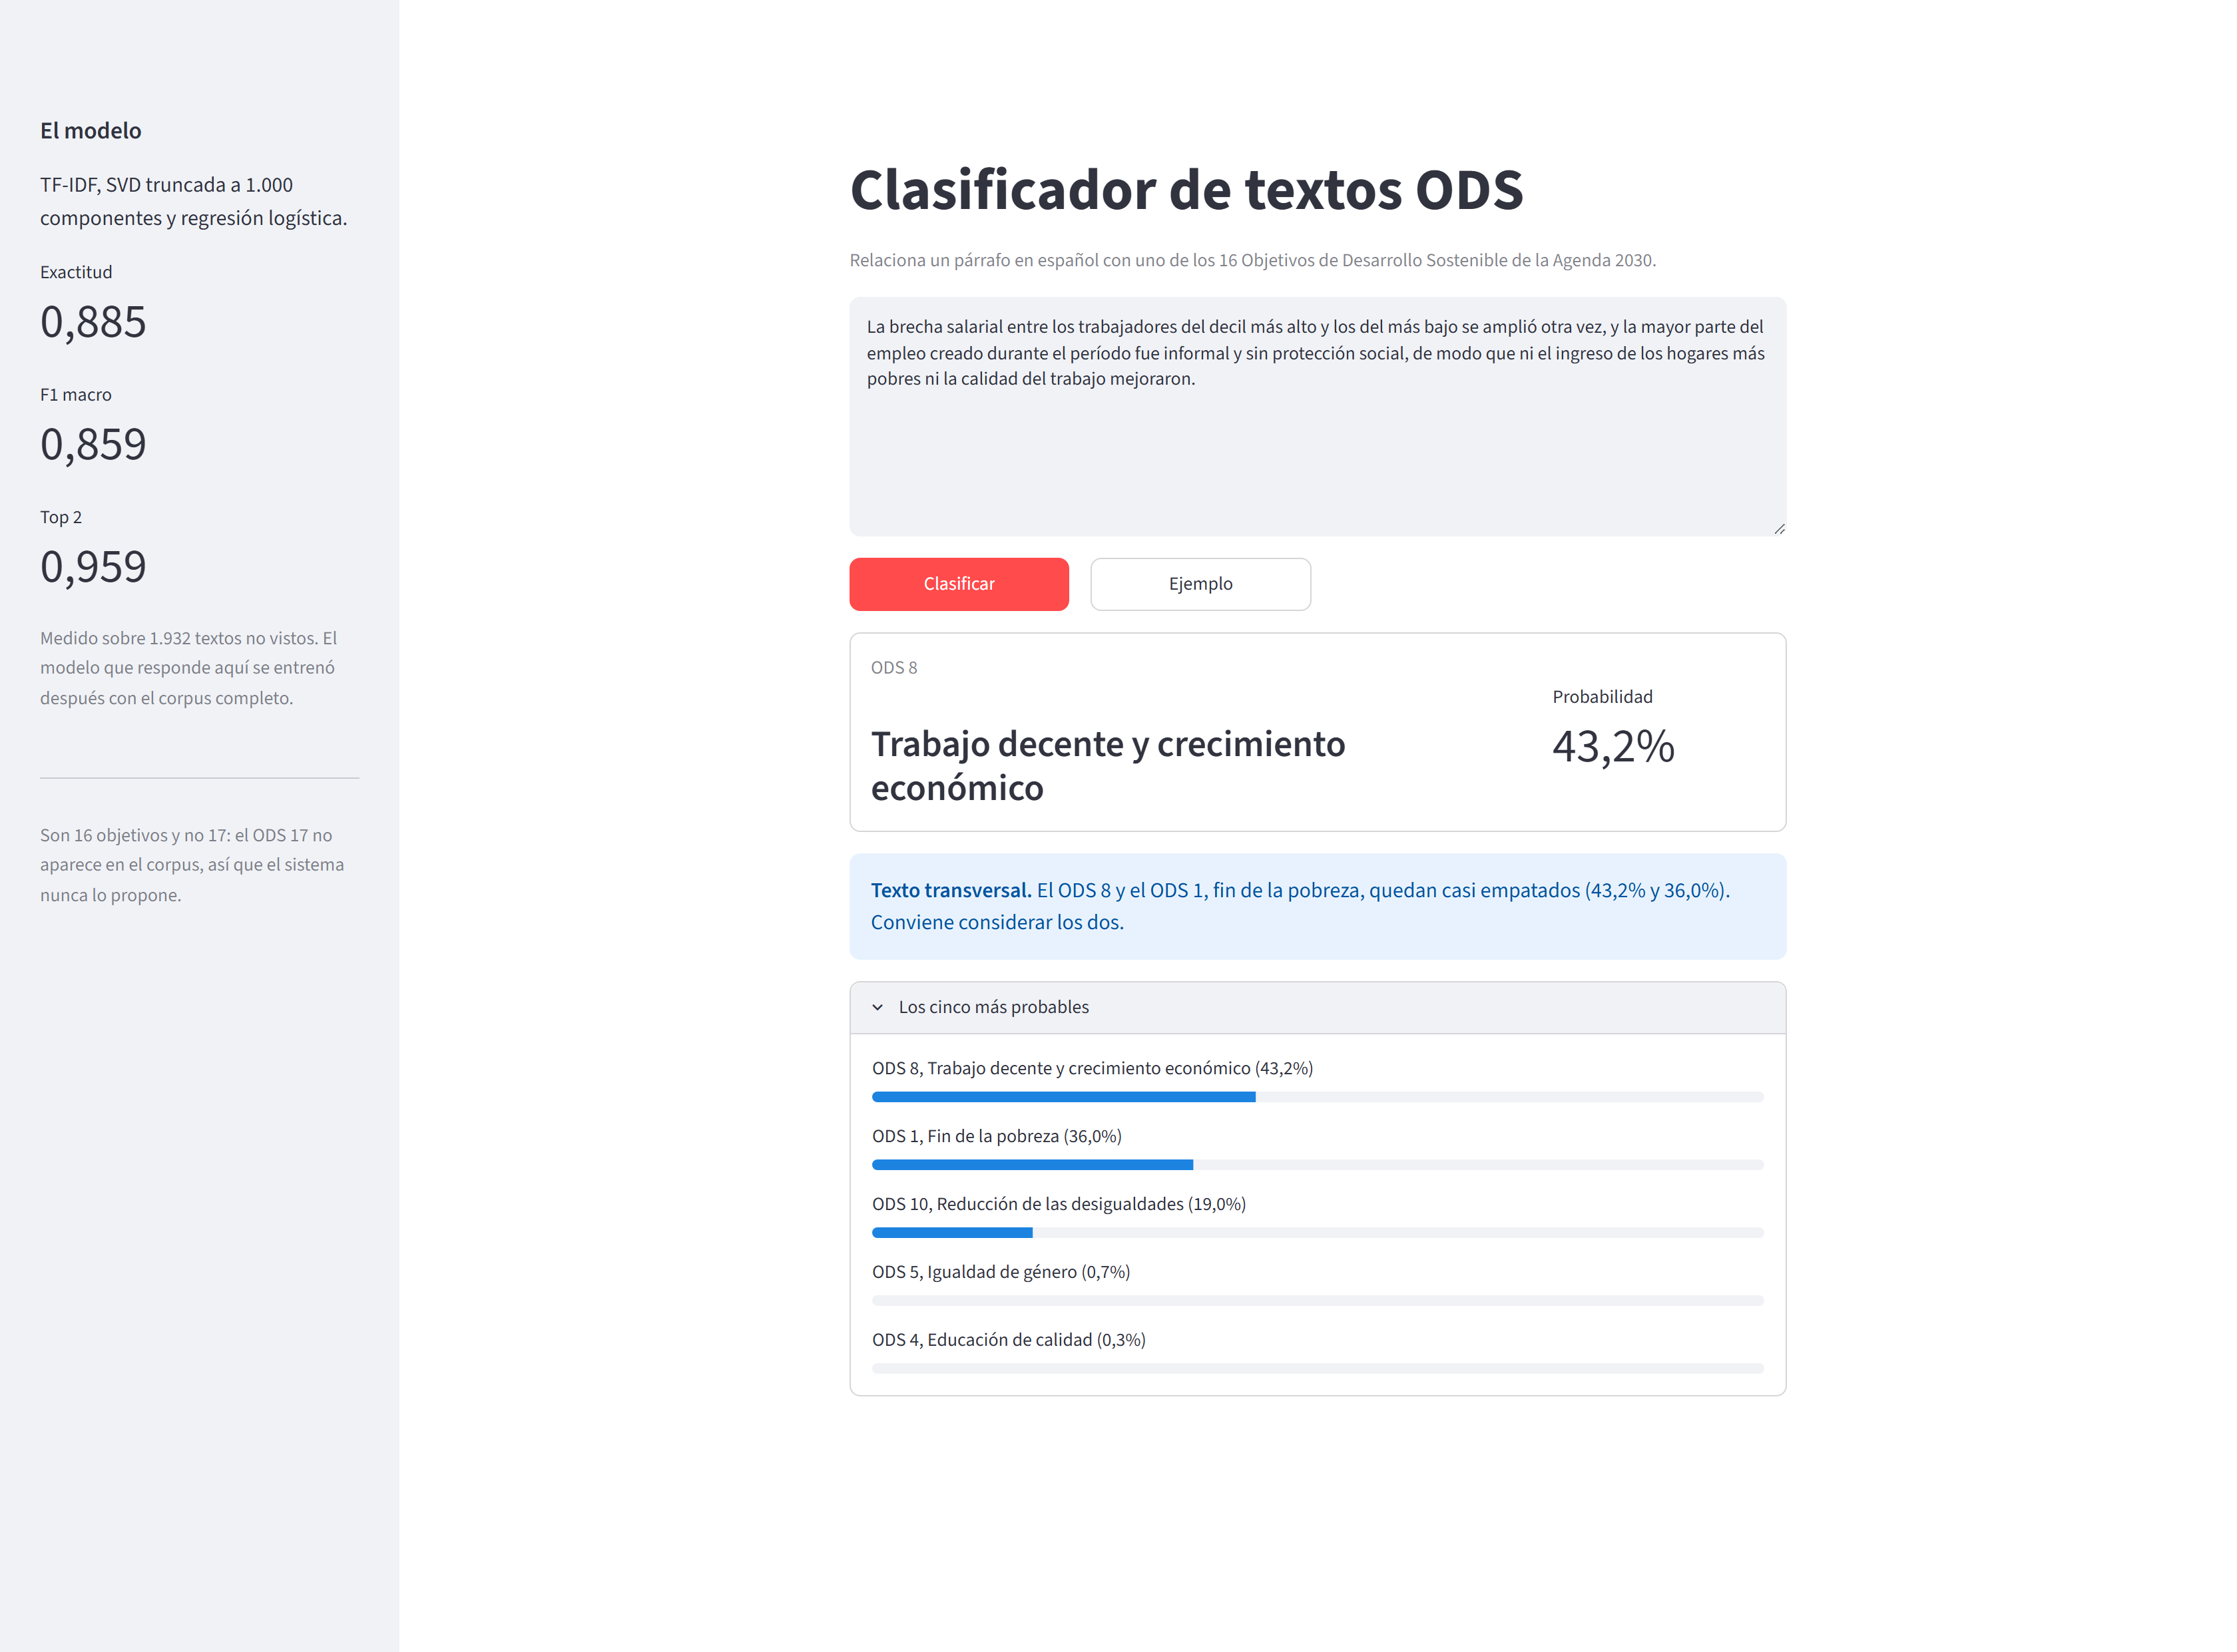

**Un texto sin vocabulario conocido.** Una cadena sin ninguna palabra del español deja el TF-IDF
en cero, y sobre esa fila vacía el modelo respondería solo con sus sesgos. La aplicación avisa
en vez de clasificar.

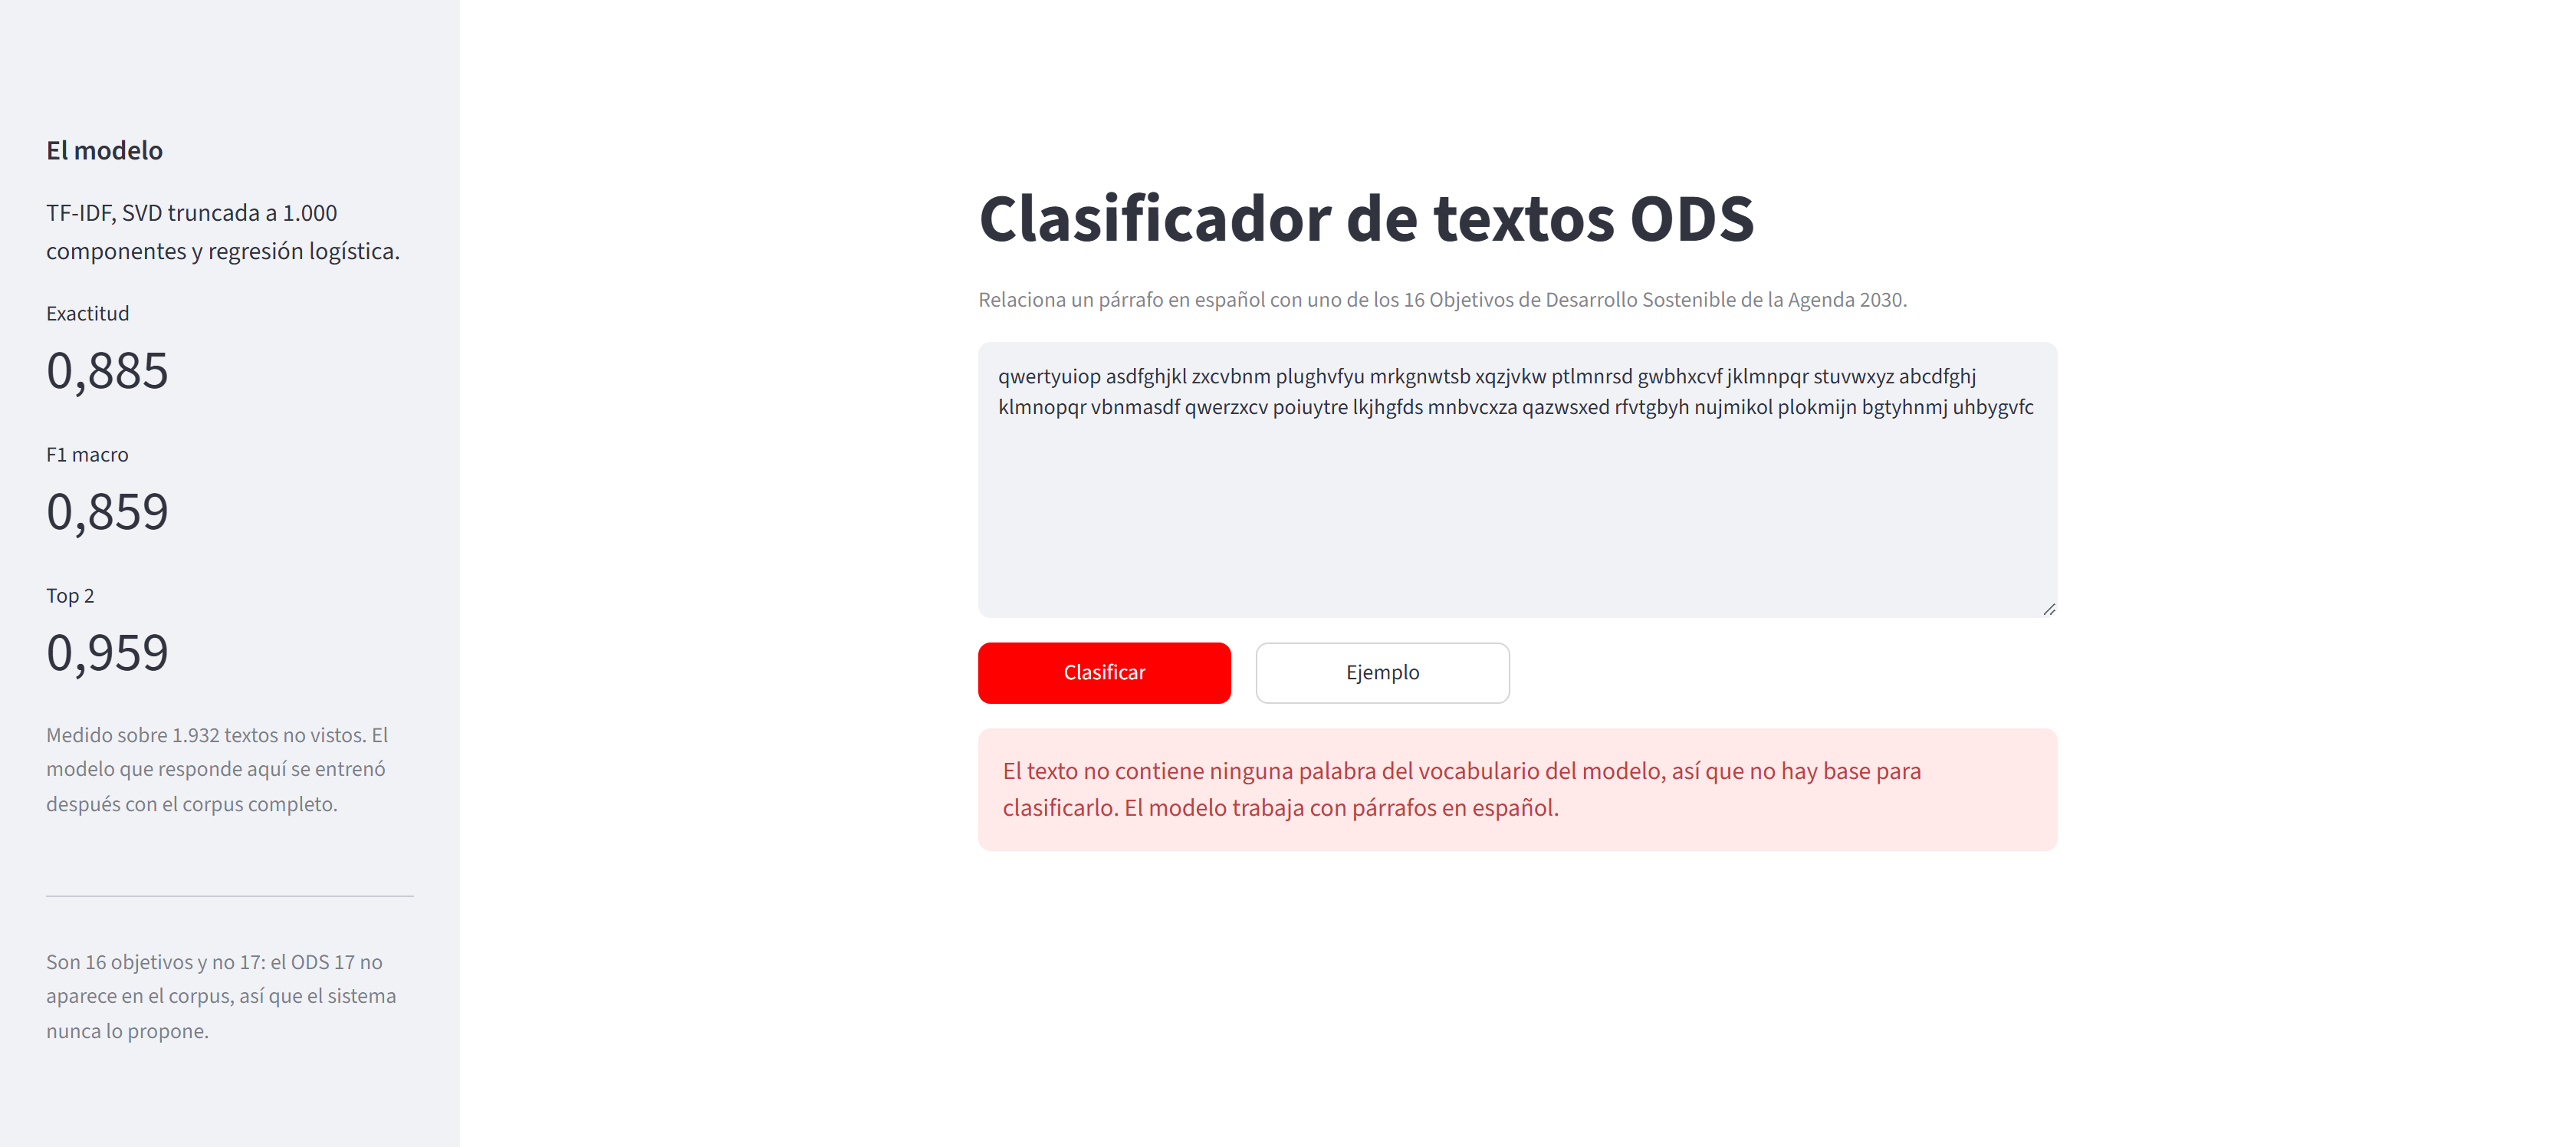